[Table of Contents](./table_of_contents.ipynb)

# Multivariate Kalman Filters
# 多元卡尔曼滤波器

Filtering Multiple Random Variables

过滤多个随机变量


In [1]:
from __future__ import division, print_function
%matplotlib inline

In [2]:
#format the book
import book_format
book_format.set_style()

## Introduction
## 介绍

We are now ready to study and implement the full, multivariate form of the Kalman filter. In the last chapter we learned how multivariate Gaussians express the correlation between multiple random variables, such as the position and velocity of an aircraft. We also learned how correlation between variables drastically improves the posterior. If we only roughly know position and velocity, but they are correlated, then our new estimate can be very accurate.

我们现在已经准备好研究和实现完整的卡尔曼滤波器多变量形式。在上一章中，我们学习了多变量高斯函数如何表达多个随机变量之间的相关性，例如飞机的位置和速度。我们还了解了变量之间的相关性是如何显著改善后验。如果我们只粗略地知道位置和速度，但它们是相关的，那么我们的新估计就可以非常准确。

I prefer that you develop an intuition for how these filters work through several worked examples. I'm going to gloss over many issues. Some things I show you will only work for special cases, others will be 'magical' - it will not be clear how I derived a certain result. If I started with rigorous, generalized equations you would be left scratching your head about what all these terms mean and how you might apply them to your problem. In later chapters I will provide a more rigorous mathematical foundation, and at that time I will have to either correct approximations that I made in this chapter or provide additional information that I did not cover here. 

我希望您能够通过几个已经可以运行的例子来开发 这些滤波器是如何工作的直觉。我要掩盖许多问题。我向你们展示的一些东西只适用于特殊情况，其他的将是“神奇的”——不清楚我是如何得出某种结果的。如果我从严格的、广义的方程开始，你会对所有这些术语的含义以及如何将它们应用于你的问题感到头疼。在后面的章节中，我将提供一个更严格的数学基础，在那个时候，我将必须纠正我在本章中所做的近似，或者提供我在这里没有涵盖的额外信息。 

To make this possible we will restrict ourselves to a subset of problems which we can describe with Newton's equations of motion. These filters are called *discretized continuous-time kinematic filters*. In the **Kalman Filter Math** chapter we will develop the math for non-Newtonian systems. 

为了使这成为可能，我们将我们解决的问题局限于我们可以用牛顿运动方程描述的问题的子集。 这些滤波器称为*离散连续时间运动滤波器*。 在**卡尔曼滤波器的数学推导**一章中，我们将开发非牛顿系统的数学运算。

## Newton's Equations of Motion
## 牛顿运动方程

Newton's equations of motion tells us that given a constant velocity $v$ of a system we can compute its position $x$ after time $t$ with:

牛顿运动方程告诉我们，对于一个具有恒定速度$ v $系统，我们可以计算出时间$ t $之后其位置$ x $：

$$x = vt + x_0$$

For example, if we start at position 13, our velocity is 10 m/s, and we travel for 12 seconds our final position is 133 ($10\times 12 + 13$).

例如，如果我们从13米的位置开始，我们的速度是10米/秒，我们运动12秒，我们的最终位置是133（$ 10\times 12 + 13 $）。

We can incorporate constant acceleration with this equation

我们可以给这个等式加入恒定加速度

$$x = \frac{1}{2}at^2 + v_0t + x_0$$

And if we assume constant jerk we get

如果我们假设我们得到持续的猛推

$$x = \frac{1}{6}jt^3 +  \frac{1}{2}a_0 t^2 + v_0 t + x_0$$

These equations were generated by integrating a differential equation. Given a constant velocity v we can compute the distance traveled over time with the equation

这些方程是通过积分微分方程生成的。 给定恒定速度v，我们可以用等式计算物体随时间移动的距离

$$x = vt + x_0$$

which we can derive with

我们可以推导出

$$\begin{aligned} v &= \frac{dx}{dt}\\
dx &= v\, dt \\
\int_{x_0}^x\, dx &= \int_0^t v\, dt\\
x - x_0 &= vt - 0\\
x &= vt + x_0\end{aligned}$$


When you design a Kalman filter you start with a system of differential equations that describe the dynamics of the system. Most systems of differential equations do not easily integrate in this way. We start with Newton's equation because we can integrate and get a closed form solution, which makes the Kalman filter easier to design. An added benefit is that Newton's equations are the right equations to use to track moving objects, one of the main uses of Kalman filters.

设计卡尔曼滤波器时，首先要使用描述系统动力学的微分方程组。 大多数微分方程系统不容易以这种方式集成。 我们从牛顿方程开始，因为我们可以集成并得到一个封闭形式的解决方案，这使得卡尔曼滤波器更容易设计。 另一个好处是，牛顿方程是用于跟踪移动物体的方程，这也是卡尔曼滤波器的主要用途之一。

## Kalman Filter Algorithm
## 卡尔曼滤波器算法

The algorithm is the same Bayesian filter algorithm that we have used in every chapter. The update step is slightly more complicated, but I will explain why when we get to it.

该算法与我们在每一章中使用的贝叶斯滤波算法相同。 更新步骤稍微复杂一点，但我会解释为什么我们到达它。

**Initialization**

    1. Initialize the state of the filter
    2. Initialize our belief in the state

**初始化**

    1. 初始化滤波器状态
    2. 初始化状态的置信度
    
**Predict**

    1. Use process model to predict state at the next time step
    2. Adjust belief to account for the uncertainty in prediction    
    
**预测**
    
    1. 使用过程模型预测下一时间点的状态
    2. 根据预测结果的不确定性调整置信度

**Update**

    1. Get a measurement and associated belief about its accuracy
    2. Compute residual between estimated state and measurement
    3. Compute scaling factor based on whether the measurement
    or prediction is more accurate
    4. set state between the prediction and measurement based 
    on scaling factor
    5. update belief in the state based on how certain we are 
    in the measurement
**更新**

    1. 获得系统的测量值和有关准确性的置信度
    2. 计算状态估计和测量值的残差
    3. 基于测量值和预测值的准确性计算比例因子
    4. 根据比例因子计算位于预测值和测量值之间的状态
    5. 根据我们对测量值的确定性更新状态的置信度
    
As a reminder, here is a graphical depiction of the algorithm:

提醒一下，下面是算法的图形描述：

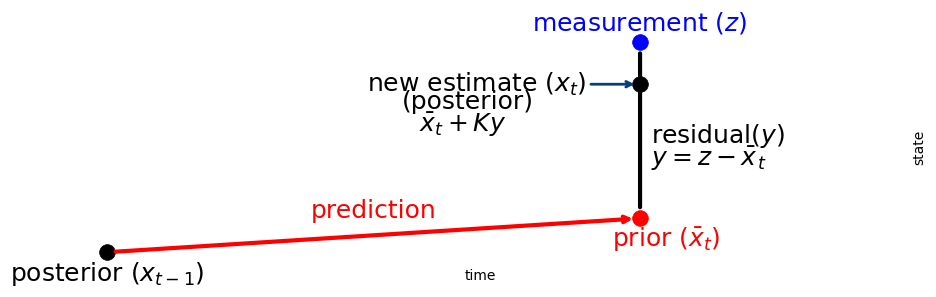

In [3]:
import kf_book.book_plots as book_plots
book_plots.show_residual_chart()

The univariate Kalman filter represented the state with a univariate Gaussian. Naturally the multivariate Kalman filter will use a multivariate Gaussian for the state. We learned in the last chapter that multivariate Gaussians use a vector for the mean and a matrix for the covariances. That means that the Kalman filter needs to use linear algebra to perform the estimations.

单变量卡尔曼滤波器用单变量高斯表示状态。那么，多元卡尔曼滤波器就要使用多元高斯分布来表示状态。 我们在上一章中了解到，多元高斯使的均值为向量，协方差是一个矩阵。这意味着卡尔曼滤波器需要使用线性代数来执行估计。

I don't want you to memorize these equations, but I have listed the univariate and multivariate equations below. They are quite similar.

我不想让你记住这些方程，但我列出了下面的单变量和多变量方程。 它们非常相似。

<u>**预测**</u>

$\begin{array}{|l|l|l|}
\hline
\text{Univariate} & \text{Univariate} & \text{Multivariate}\\
& \text{(Kalman form)} & \\
\hline
\bar \mu = \mu + \mu_{f_x} & \bar x = x + dx & \bar{\mathbf x} = \mathbf{Fx} + \mathbf{Bu}\\
\bar\sigma^2 = \sigma_x^2 + \sigma_{f_x}^2 & \bar P = P + Q & \bar{\mathbf P} = \mathbf{FPF}^\mathsf T + \mathbf Q \\
\hline
\end{array}$

Without worrying about the specifics of the linear algebra, we can see that:

不必担心线性代数的细节，我们可以看到：

$\mathbf x,\, \mathbf P$ are the state mean and covariance. They correspond to $x$ and $\sigma^2$.

$ \mathbf x,\,\mathbf P$是状态均值和协方差。 它们对应于单变量的$ x $和$ \sigma ^ 2 $。

$\mathbf F$ is the *state transition function*. When multiplied by $\bf x$ it computes the prior. 

$ \mathbf F$是*状态转换函数*。 当它乘以$ \bf x $时，会计算得到先验值。

$\mathbf Q$ is the process covariance. It corresponds to $\sigma^2_{f_x}$.

$ \mathbf Q$是过程协方差。 它对应单变量的于$ \sigma^2_{f_x} $。

$\mathbf B$ and $\mathbf u$ are new to us. They let us model control inputs to the system.

$ \mathbf B $和$ \mathbf u $对我们来说是新的变量。 他们让我们的模拟控制系统的输入。

<u>**更新**</u>

$\begin{array}{|l|l|l|}
\hline
\text{Univariate} & \text{Univariate} & \text{Multivariate}\\
& \text{(Kalman form)} & \\
\hline
& y = z - \bar x & \mathbf y = \mathbf z - \mathbf{H\bar x} \\
& K = \frac{\bar P}{\bar P+R}&
\mathbf K = \mathbf{\bar{P}H}^\mathsf T (\mathbf{H\bar{P}H}^\mathsf T + \mathbf R)^{-1} \\
\mu=\frac{\bar\sigma^2\, \mu_z + \sigma_z^2 \, \bar\mu} {\bar\sigma^2 + \sigma_z^2} & x = \bar x + Ky & \mathbf x = \bar{\mathbf x} + \mathbf{Ky} \\
\sigma^2 = \frac{\sigma_1^2\sigma_2^2}{\sigma_1^2+\sigma_2^2} & P = (1-K)\bar P &
\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar{P}} \\
\hline
\end{array}$

$\mathbf H$ is the measurement function. We haven't seen this yet in this book and I'll explain it later. If you mentally remove $\mathbf H$ from the equations, you should be able to see these equations are similar as well.

$ \mathbf H $是测量函数。我们在本书中还没有看到这个，我稍后会解释它。如果你从方程中删掉$ \mathbf H $，你应该能够看到这些方程式也是相似的。

$\mathbf z,\, \mathbf R$ are the measurement mean and noise covariance. They correspond to $z$ and $\sigma_z^2$ in the univariate filter (I've substituted $\mu$ with $x$ for the univariate equations to make the notation as similar as possible).

$ \mathbf z,\,\mathbf R $是测量平均值和噪声协方差。 它们对应于单变量滤波器中的$ z $和$ \sigma_z ^ 2 $（我用$ x $替换单变量方程中的$ \mu $，以使符号尽可能相似）。

$\mathbf y$ and $\mathbf K$ are the residual and Kalman gain. 

$ \mathbf y $和$ \mathbf K $是残差和卡尔曼增益。

The details will be different than the univariate filter because these are vectors and matrices, but the concepts are exactly the same: 

多变量滤波的细节将与单变量滤波器不同，因为它们是向量和矩阵，但概念完全相同：

-  Use a Gaussian to represent our estimate of the state and error
-  Use a Gaussian to represent the measurement and its error
-  Use a Gaussian to represent the process model
-  Use the process model to predict the next state (the prior)
-  Form an estimate part way between the measurement and the prior

 - 使用高斯分布来表示我们对状态和误差的估计
 - 使用高斯分布表示测量及其误差
 - 使用高斯分布来表示过程模型
 - 使用过程模型预测下一个状态（先验）
 - 在测量值和先验值之间形成估计

Your job as a designer will be to design the state $\left(\mathbf x, \mathbf P\right)$, the process $\left(\mathbf F, \mathbf Q\right)$, the measurement $\left(\mathbf z, \mathbf R\right)$, and the  measurement function $\mathbf H$. If the system has control inputs, such as a robot, you will also design $\mathbf B$ and $\mathbf u$.

你作为设计者的工作就是设计状态$ \left(\mathbf x,\mathbf P \right)$，过程$ \left(\mathbf F,\mathbf Q \right)$，测量值$ \left (\mathbf z,\mathbf R \right)$，以及测量函数$ \mathbf H $。 如果系统具有控制输入，例如机器人，您还将设计$ \mathbf B $和$ \mathbf u $。

I have programmed the equations of the Kalman filter into the `predict` and `update` functions in FilterPy. You will import them with:

我已经将卡尔曼滤波器的方程封装为FilterPy中的`predict`和`update`函数。 您可以很方便地导入它们：

```python
from filterpy.kalman import predict, update
```

## Tracking a Dog
## 跟踪狗

Let's go back to our tried and true problem of tracking a dog. This time we will include the fundamental insight of the previous chapter and use *hidden variables* to improve our estimates. I could start with the math, but instead let's implement a filter, learning as we go. On the surface the math is different and perhaps more complicated than the previous chapters, but the ideas are all the same - we are just multiplying and adding Gaussians.

让我们回到我们追踪狗的问题。 这次我们将包括前一章的基本见解，并使用*隐藏变量*来改进我们的估计。我从数学推导开始，但是随着我们的学习，最终会实现一个滤波器器。 从表面上看，数学公式是不同的，也许比前面的章节更复杂，但是基础的思想都是相同的——我们只是乘以和加上了高斯分布。

We start by writing a simulation for the dog. The simulation will run for `count` steps, moving the dog forward approximately 1 meter for each step. At each step the velocity will vary according to the process variance `process_var`. After updating the position we compute a measurement with an assumed sensor variance of `z_var`. The function returns an NumPy array of the positions and another of the measurements.

我们首先为狗写一个模拟器。这个模拟器将“统计”移动的步数，每步向前移动约1米。在每一步中，速度会根据过程方差`process_var`而变化。位置更新后，我们使用假定的传感器方差`z_var`计算测量值。该函数返回位置的NumPy数组和另一个测量值。

In [4]:
import math
import numpy as np
from numpy.random import randn

def compute_dog_data(z_var, process_var, count=1, dt=1.):
    "returns track, measurements 1D ndarrays"
    x, vel = 0., 1.
    z_std = math.sqrt(z_var) 
    p_std = math.sqrt(process_var)
    xs, zs = [], []
    for _ in range(count):
        v = vel + (randn() * p_std)
        x += v*dt        
        xs.append(x)
        zs.append(x + randn() * z_std)        
    return np.array(xs), np.array(zs)

## Predict Step
## 预测步骤

For the prediction we need to design the state and covariance, the process model and the process noise, and optionally the control input. We'll take them in order.

对于预测，我们需要设计状态和协方差，过程模型和过程噪声，以及可选的控制输入。 我们下面会把它们整理好。

### Design State Variable
### 设计状态变量

We previously tracked a dog in one dimension by using a Gaussian. The mean $(\mu)$ represented the most likely position, and the variance ($\sigma^2$) represented the probability distribution of the position. The position is the *state* of the system, and we call $\mu$ the *state variable*. 

我们之前通过使用高斯分布来跟踪一维平面中的狗。 平均值$(\mu)$表示最可能的位置，方差（$ \sigma ^ 2 $）表示位置的概率分布。 位置就是系统的*状态*，所以我们将$ \mu $称为*状态变量*。

In this problem we will be tracking both the position and velocity of the dog. This requires us to use a multivariate Gaussian represented with the state vector $\mathbf x$ and its corresponding covariance matrix $\mathbf P$. 

在现在问题中，我们将跟踪狗的位置和速度。 这要求我们使用状态向量$ \mathbf x $表示的多元高斯及其对应的协方差矩阵$ \mathbf P $。

State variables can either be *observed variables* - directly measured by a sensor, or *hidden variables* - inferred from the observed variables. For our dog tracking problem the sensor only reads position, so position is observed and velocity is hidden. We will learn how to track hidden variables soon.

状态变量可以是*观察变量* ——由传感器直接测量得到，或*隐藏变量* ——通过观察变量推断得出。 对于追踪狗的问题，传感器只能读取到位置信息，因此位置是观察变量，而速度是隐藏变量。 我们将学习如何快速跟踪隐藏变量。

It is important to understand that tracking position and velocity is a design choice with implications and assumptions that we are not yet prepared to explore. For example, we could also track acceleration, or even jerk. For now, recall that in the last chapter we showed that including velocity in the covariance matrix resulted in much smaller variances in position. We will learn how the Kalman filter computes estimates for hidden variables later in this chapter. 

重要的是你要知道选择跟踪位置和速度只是一种设计思路，其含义和假设未知需要探索。例如，我们也可以跟踪加速度，甚至是激励信号。 现在，回想一下，在上一章中，我们发现在协方差矩阵中包含速度会导致位置变化小得多。我们将在本章后面学习卡尔曼滤波器如何计算隐藏变量的估计值。

In the univariate chapter we represented the dog's position with a scalar value (e.g. $\mu=3.27$). In the last chapter we learned to use a multivariate Gaussian for multiple variables. For example, if we wanted to specify a position of 10.0 m and a velocity of 4.5 m/s, we would write:

在单变量章节中，我们用标量值表示狗的位置（例如$ \mu = 3.27 $）。 在上一章中，我们学会了使用多元高斯分布来表示多个变量。 例如，如果我们想要指定10.0米的位置和4.5米/秒的速度，我们会写：

$$\mu = \begin{bmatrix}10.0\\4.5\end{bmatrix}$$

The Kalman filter is implemented using linear algebra. We use an $n\times 1$ matrix (called a *vector*) to store  $n$ state variables. For the dog tracking problem, we use $x$ to denote position, and the first derivative of $x$, $\dot x$, for velocity. I use Newton's dot notation for derivatives; $\dot x$ represents the first derivative of x with respect to t: $\dot x = \frac{dx}{dt}$. Kalman filter equations use $\mathbf x$ for the state, so we define $\mathbf x$ as:

卡尔曼滤波器使用线性代数实现。我们使用$ n \times 1 $矩阵（称为* vector* ）来存储$ n $个状态变量。对于追踪狗的问题，我们使用$ x $表示位置，以及$ x $的一阶导数，$ \dot x $，表示速度。 我使用牛顿的点符号来表示衍生物; $ \dot x $表示x相对于t的一阶导数：$ \dot x = \frac {dx} {dt} $。 卡尔曼滤波器方程使用$ \mathbf x $表示状态，因此我们将$ \mathbf x $定义为：

$$\mathbf x =\begin{bmatrix}x \\ \dot x\end{bmatrix}$$

We use $\mathbf x$ instead of $\mu$, but recognize this is the mean of the multivariate Gaussian.

我们使用$ \mathbf x $而不是$ \mu $，是因为这是多元高斯的平均值。

Another way to write this is $\mathbf x =\begin{bmatrix}x & \dot x\end{bmatrix}^\mathsf T$ because the transpose of a row vector is a column vector. This notation is easier to use in text because it takes less vertical space.

写这个的另一种方法是$ \mathbf x = \begin {bmatrix} x & \dot x \end {bmatrix} ^ \mathsf T $，因为行向量的转置是列向量。 这种表示法在文本中更容易使用，因为它占用的垂直空间更少。

$\mathbf x$ and the position $x$ coincidentally have the same name. If we were tracking the dog in the y-axis we would write $\mathbf x =\begin{bmatrix}y & \dot y\end{bmatrix}^\mathsf T$, not  $\mathbf y =\begin{bmatrix}y & \dot y\end{bmatrix}^\mathsf T$. $\mathbf x$ is the standard name for the state variable used in the Kalman filter literature and we will not vary it to give it a more meaningful name. This consistency in naming allows us to communicate with our peers.

$ \mathbf x $和位置$ x $巧合地具有相同的名称。 如果我们在y轴上跟踪狗，我们会写$ \mathbf x = \begin {bmatrix} y&\dot y \end {bmatrix} ^ \mathsf T $，而不是$\mathbf y = \begin {bmatrix } y & \dot y \end {bmatrix}^\mathsf T$ 。 $ \mathbf x $是卡尔曼滤波器文献中使用的状态变量的标准名称，我们不会改变它以给它一个更有意义的名称。 这种命名的一致性使我们能够与同行进行沟通。

Let's code this. Initialization of `x` is as simple as

我们来进行编码吧。 `x`的初始化很简单

In [5]:
x = np.array([[1000.0],
              [4.5]])
x

array([[1000. ],
       [   4.5]])

I often use the transpose in my code to turn a row matrix into a column vector, as I find it easier to type and read:

我经常在我的代码中使用转置将行矩阵转换为列向量，因为我发现它更容易输入和读取：

In [6]:
x = np.array([[10., 4.5]]).T
x

array([[10. ],
       [ 4.5]])

However, NumPy recognizes 1D arrays as vectors, so I can simplify this line to use a 1D array.

由于NumPy将1维数组识别为向量，因此我可以使用1维数组简化。

In [7]:
x = np.array([10.0, 4.5])
x

array([10. ,  4.5])

All of the array elements have the same type, typically either `float` or `int`. If the list contains all `int`s then the created array will also have a data type of `int`, otherwise it will be `float`. I will often take advantage of this by only specifying one number as a floating point:

所有数组元素都具有相同的类型，通常是`float`或`int`。 如果列表所有元素都是`int`，那么创建的数组也将具有`int`的数据类型，否则它将是`float`。 我利用这一特性，会经常仅通过指定一个数字为浮点数：

In [8]:
np.array([1., 0, 0, 0, 0, 0])

array([1., 0., 0., 0., 0., 0.])

Here are some examples.

下面给出一些示例。


In [9]:
A = np.array([[1, 2], [3, 4]])
x = np.array([[10.0], [4.5]])

# matrix multiply
print(np.dot(A, x))
print()

x = np.array([[10.0, 4.5]]).T
print(np.dot(A, x))
print()

x = np.array([10.0, 4.5])
print(np.dot(A, x))

[[19.]
 [48.]]

[[19.]
 [48.]]

[19. 48.]


The last returns a 1D array, but I have written the Kalman filter class to be able to handle this. In retrospect that might lead to confusion, but it does work. 

最后一个返回1维数组，但我已经编写了卡尔曼滤波器类来处理这个问题。 回想起来，这可能会导致混乱，但确实有效。

### Design State Covariance
### 设计状态协方差

The other half of the state Gaussian is the covariance matrix $\mathbf P$. In the univariate Kalman filter we specified an initial value for $\sigma^2$, and then the filter took care of updating its value as measurements were added to the filter. The same thing happens in the multidimensional Kalman filter. We specify an initial value for $\mathbf P$ and the filter updates it during each epoch.

状态高斯的另一一个部分是协方差矩阵$ \mathbf P $。 在单变量卡尔曼滤波器中，我们为$ \sigma ^ 2 $指定了初始值，然后当滤波器中添加了测量值时，滤波器会更新其值。 在多维卡尔曼滤波器中也会发生同样的事情。 我们为$ \mathbf P $指定一个初始值，滤波器会在每个步骤中更新它。

We need to set the variances to reasonable values. For example, we may choose $\sigma_\mathtt{pos}^2=500 m^2$ if we are quite uncertain about the initial position. Top speed for a dog is around 21 m/s, so in the absence of any other information about the velocity we can set $3\sigma_\mathtt{vel}=21$, or $\sigma_\mathtt{vel}^2=7^2=49$. 

我们需要将方差设置为合理的值。例如，如果我们对初始位置非常不确定，我们可以选择$ \sigma_ \mathtt {pos} ^ 2 = 500 m^2$。狗的最高速度大约是21米/秒，所以在没有关于速度的任何其他信息的情况下我们可以设置速度的方差$ 3 \sigma_ \mathtt {vel} = 21 $，或$ \sigma_ \mathtt {vel} ^ 2 =7^ 2 =49$。

In the last chapter we showed that the position and velocities are correlated. But how correlated are they for a dog? I have no idea. As we will see the filter computes this for us, so I initialize the covariances to zero. Of course, if you know the covariances you should use them.

在上一章中，我们可以知道位置和速度是相关的。但他们对于狗有多相关？我不知道。我们接下来会看到滤波器如何计算他们的协方差，所以我先将协方差初始化为零。 当然，如果你知道协方差，你可以设置它。

Recall that the diagonals of the covariance matrix contains the variance of each variable, and the off-diagonal elements contains the covariances. Thus we have:

回想一下，协方差矩阵的对角线是每个变量的方差，而非对角线元是协方差。 因此我们有：

$$
\mathbf P = \begin{bmatrix}500 & 0 \\ 0&49\end{bmatrix}
$$

We can use `numpy.diag`, which creates a diagonal matrix from the values for the diagonal. Recall from linear algebra that a diagonal matrix is one with zeros in the off-diagonal elements.

我们可以使用`numpy.diag`，它将根据对角线的值创建一个对角矩阵。 回想一下线性代数，对角矩阵是非对角线的元素是零。

In [10]:
P = np.diag([500., 49.])
P

array([[500.,   0.],
       [  0.,  49.]])

I could have written:

我可以写成这样

In [11]:
P = np.array([[500., 0.],
              [0., 49.]])
P

array([[500.,   0.],
       [  0.,  49.]])

We are done. We've expressed the state of the filter as a multivariate Gaussian and implemented it in code.

现在，我们已经将滤波器的状态表示为多元高斯，并在代码中实现了它。

###  Design the Process Model
### 设计过程模型

The next step is designing the *process model*. It is a mathematical model which describes the behavior of the system. The filter uses it to predict the state after a discrete time step. We do this with a set of equations that describe the dynamics of the system.

下一步是设计*过程模型*。 它是描述系统行为的数学模型。 滤波器使用它来预测一个离散时间步长之后的状态。 我们用一组描述系统动力学的方程式实现它。

In the univariate chapter we modeled the dog's motion with

在单变量高斯的章节中，我们用下面的公式模拟了狗的行为

$$ x = v \Delta t + x_0$$

We implemented this as follows:

实现方法如下：

```python
def predict(pos, movement):
    return gaussian(pos.mean + movement.mean, 
                    movement.var + movement.var)
```

We will do the same thing in this chapter, using multivariate Gaussians instead of univariate Gaussians. You might imagine this sort of implementation:

我们将在本章中做同样的事情，这次使用的是多元高斯而不是单变量高斯。 你可以思考下如何实现下面的方程：

$$ \mathbf x = \begin{bmatrix}5.4\\4.2\end{bmatrix}, \, \, 
\dot{\mathbf x} =  \begin{bmatrix}1.1\\0.\end{bmatrix} \\
\mathbf x = \dot{\mathbf x}t + \mathbf x$$

But we need to generalize this. The Kalman filter equations work with any linear system, not just Newtonian ones. Maybe the system you are filtering is the plumbing system in a chemical plant, and the flow in a given pipe is determined by a linear combination of the settings of different valves. 

但我们需要重申一点。卡尔曼滤波器方程适用于任何线性系统，而不仅仅是牛顿系统。 也许你滤波的系统是化工厂的管道系统，给定管道中的流量由不同阀门设置的线性组合决定。

$$\mathtt{pipe_1} = 0.134(\mathtt{valve}_1) + 0.41(\mathtt{valve}_2 - \mathtt{valve}_3) + 1.34$$
$$\mathtt{pipe_2} = 0.210(\mathtt{valve}_2) - 0.62(\mathtt{valve}_1 - \mathtt{valve}_5) + 1.86$$

Linear algebra has a powerful way to express systems of equations. Take this system

线性代数是一种表示方程组的强大方法。 对于这个系统

$$\begin{cases}
2x+3y=8\\4x-y=2
\end{cases}$$

We can put this in matrix form by writing:

我们可以写成：

$$\begin{bmatrix}2& 3 \\ 4&-1\end{bmatrix} \begin{bmatrix}x\\y\end{bmatrix} = \begin{bmatrix}8\\2\end{bmatrix}$$

If you perform the [matrix multiplication](https://en.wikipedia.org/wiki/Matrix_multiplication#General_definition_of_the_matrix_product) in this equation the result will be the two equations above. In linear algebra we would write this as $\mathbf{Ax}=\mathbf B$, where

这是上面的两个等式使用[矩阵乘法](https://en.wikipedia.org/wiki/Matrix_multiplication#General_definition_of_the_matrix_product)的结果。在线性代数中，我们将其写为$ \mathbf {Ax} = \mathbf B $，其中

$$\mathbf{A} = \begin{bmatrix}2& 3 \\ 4&-1\end{bmatrix},\, \mathbf x = \begin{bmatrix}x\\y\end{bmatrix}, \mathbf B=\begin{bmatrix}8\\2\end{bmatrix}$$

And then we can use the SciPy's `linalg` package to solve for $\mathbf x$:

我们可以使用SciPy中的`linalg`包来解决$ \mathbf x $：

In [12]:
from scipy.linalg import solve
A = np.array([[2, 3],[4, -1]])
b = np.array([[8], [2]])
x = solve(A, b)
x

array([[1.],
       [2.]])

We use the process model to perform the *innovation*, because the equations tell us what the next state will be given the current state. Kalman filters implement this using this linear equation, where $\mathbf{\bar x}$ is the *prior*, or predicted state:

我们在过程模型来执行*更新*，因为方程会告诉我们下一个状态将被赋予当前状态。卡尔曼滤波器使用这个线性方程实现这一点，其中$ \mathbf {\bar x} $是*先验值*或预测状态：

$$\mathbf{\bar x} = \mathbf{Fx}$$

which we can make explicit as

可将其明确写为

$$\begin{bmatrix} \bar x \\ \dot{\bar x}\end{bmatrix} = \begin{bmatrix}? & ? \\? & ?\end{bmatrix}\begin{bmatrix}x\\\dot x\end{bmatrix}$$

Our job as Kalman filters designers is to specify $\mathbf F$ such that $\bar{\mathbf x}  = \mathbf{Fx}$ performs the innovation (prediction) for our system. To do this we need one equation for each state variable. In our problem $\mathbf x = \begin{bmatrix}x & \dot x\end{bmatrix}^\mathtt{T}$, so we need one equation to compute the position $x$ and another to compute the velocity $\dot x$ . We already know the equation for the position innovation:

作为卡尔曼滤波器的设计者，我们的任务是指定 $\mathbf F$，使 $\bar{\mathbf x}  = \mathbf{Fx}$ 能为系统执行预测。为此，每个状态变量都需要一个方程。在这个问题中，$\mathbf x = \begin{bmatrix}x & \dot x\end{bmatrix}^\mathtt{T}$，因此需要一个方程计算位置 $x$，另一个方程计算速度 $\dot x$。位置预测的方程我们已经知道：

$$\bar x = x + \dot x \Delta t$$

What is our equation for velocity? We have no predictive model for how our dog's velocity will change over time. In this case we assume that it remains constant between innovations. Of course this is not exactly true, but so long as the velocity doesn't change too much over each innovation you will see that the filter performs very well. So we say

速度的方程是什么？对于狗的速度如何随时间变化，我们没有预测模型。在这里，我们假设它在两次预测之间保持不变。当然，这并不完全正确，但只要速度在每次预测期间变化不大，你就会发现滤波器的表现非常好。因此，我们写作

$$\bar{\dot x} = \dot x$$

This gives us the process model for our system 

由此得到系统的过程模型：

$$\begin{cases}
\begin{aligned}
\bar x &= x + \dot x \Delta t \\
\bar{\dot x} &= \dot x
\end{aligned}
\end{cases}$$

This correctly has one equation for each variable in the state, isolated on the left hand side. We need to express this set of equations in the form $\bar{\mathbf x}  = \mathbf{Fx}$. Rearranging terms makes it easier to see what to do.

这里为状态中的每个变量都正确地给出了一个方程，并将其单独放在等式左侧。我们需要将这组方程表示为 $\bar{\mathbf x}  = \mathbf{Fx}$ 的形式。重新整理各项后，就更容易看清该怎么做。

$$\begin{cases}
\begin{aligned}
\bar x &= 1x + &\Delta t\, \dot x \\
\bar{\dot x} &=0x + &1\, \dot x
\end{aligned}
\end{cases}$$

We can rewrite this in matrix form as

可以将其改写为矩阵形式：

$$\begin{aligned}
\begin{bmatrix}\bar x \\ \bar{\dot x}\end{bmatrix} &= \begin{bmatrix}1&\Delta t  \\ 0&1\end{bmatrix}  \begin{bmatrix}x \\ \dot x\end{bmatrix}\\
\mathbf{\bar x} &= \mathbf{Fx}
\end{aligned}$$

$\mathbf F$ is called the *state transition function* or the *state transition matrix*. In later chapters it will be a true function, not a  matrix, so calling it a function is a bit more general.

$\mathbf F$ 称为*状态转移函数*或*状态转移矩阵*。在后续章节中，它将是一个真正的函数，而非矩阵，因此称它为函数更具一般性。


In [13]:
dt = 0.1
F = np.array([[1, dt],
              [0, 1]])
F

array([[1. , 0.1],
       [0. , 1. ]])

Let's test this! FilterPy has a `predict` method that performs the prediction by computing $\mathbf{\bar x} = \mathbf{Fx}$. Let's call it and see what happens. We've set the position to 10.0 and the velocity to  4.5 meter/sec. We've defined `dt = 0.1`, which means the time step is 0.1 seconds, so we expect the new position to be 10.45 meters after the innovation. The velocity should be unchanged.

来测试一下。FilterPy 提供了 `predict` 方法，它通过计算 $\mathbf{\bar x} = \mathbf{Fx}$ 来执行预测。让我们调用它，看看会发生什么。我们将位置设为 10.0，速度设为 4.5 米/秒。我们定义了 `dt = 0.1`，这意味着时间步长为 0.1 秒，因此预测后新位置应为 10.45 米。速度应保持不变。


In [14]:
from filterpy.kalman import predict

x = np.array([10.0, 4.5])
P = np.diag([500, 49])
F = np.array([[1, dt], [0, 1]])

# Q is the process noise
x, P = predict(x=x, P=P, F=F, Q=0)
print('x =', x)

x = [10.45  4.5 ]


This worked. If we call `predict()` several times in a row the value will be updated each time. 

运行成功。如果连续多次调用 `predict()`，该值每次都会更新。


In [15]:
for _ in range(4):
    x, P = predict(x=x, P=P, F=F, Q=0)
    print('x =', x)

x = [10.9  4.5]
x = [11.35  4.5 ]
x = [11.8  4.5]
x = [12.25  4.5 ]


`predict()` computes both the mean and covariance of the innovation. This is the value of $\mathbf P$ after five innovations (predictions), which we denote $\mathbf{\bar P}$ in the Kalman filter equations.

`predict()` 同时计算预测的均值和协方差。这是在进行了五次预测后 $\mathbf P$ 的值，在卡尔曼滤波器方程中，我们将其记为 $\mathbf{\bar P}$。


In [16]:
print(P)

[[512.25  24.5 ]
 [ 24.5   49.  ]]


Inspecting the diagonals shows us that the position variance got larger. We've performed five prediction steps with no measurements, and our uncertainty grew. The off-diagonal elements became non-zero - the Kalman filter detected a correlation between position and velocity! The variance of the velocity did not change.

查看对角线元素可知，位置方差变大了。我们在没有测量的情况下执行了五次预测步骤，不确定性随之增长。非对角线元素变为非零，卡尔曼滤波器检测到了位置和速度之间的相关性。速度的方差没有变化。

Here I plot the covariance before and after the prediction. The initial value is in solid red, and the prior (prediction) is in dashed black. I've altered the covariance and time step to better illustrate the change.

这里绘制了预测前后的协方差。初始值以红色实线表示，先验值，即预测值，以黑色虚线表示。为了更清楚地展示这种变化，我调整了协方差和时间步长。


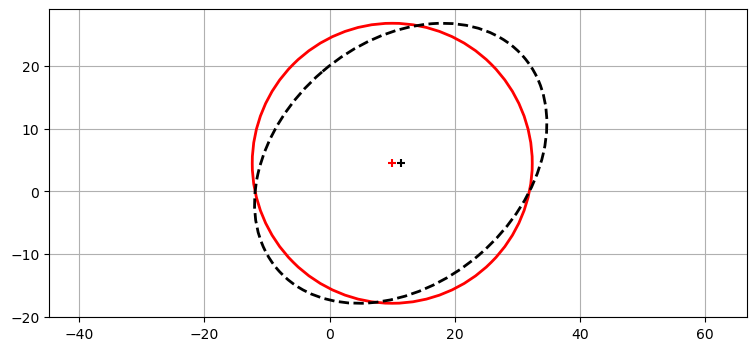

In [17]:
from filterpy.stats import plot_covariance_ellipse

dt = 0.3
F = np.array([[1, dt], [0, 1]])
x = np.array([10.0, 4.5])
P = np.diag([500, 500])
plot_covariance_ellipse(x, P, edgecolor='r')
x, P = predict(x, P, F, Q=0)
plot_covariance_ellipse(x, P, edgecolor='k', ls='dashed')

You can see that the center of the ellipse shifted by a small amount (from 10 to 11.35) because the position changed. The ellipse also elongated, showing the correlation between position and velocity. How does the filter compute new values for $\mathbf{\bar P}$, and what is it based on? Note that I set the process noise `Q` to zero each time, so it is not due to me adding noise. It's a little to early to discuss this, but recall that in every filter so far the predict step entailed a loss of information. The same is true here. I will give you the details once we have covered a bit more ground.

可以看到，由于位置发生变化，椭圆的中心发生了小幅移动，从 10 移至 11.35。椭圆也被拉长，显示出位置和速度之间的相关性。滤波器如何计算 $\mathbf{\bar P}$ 的新值，又以什么为依据？请注意，我每次都将过程噪声 `Q` 设为零，因此这并不是由于我加入了噪声。现在讨论这个还为时过早，但请回想一下，迄今为止每种滤波器的预测步骤都会造成信息损失。这里也是如此。等我们再学习一些内容后，我会给出细节。


### Design Process Noise
### 设计过程噪声

A quick review on *process noise*. A car is driving along the road with the cruise control on; it should travel at a constant speed. We model this with $\bar x_k=\dot x_k\Delta t + x_{k-1}$. However, it is affected by a number of unknown factors. The cruise control cannot perfectly maintain a constant velocity. Winds affect the car, as do hills and potholes. Passengers roll down windows, changing the drag profile of the car. 

快速回顾一下*过程噪声*。一辆汽车正沿道路行驶，且开启了巡航控制，它应当以恒定速度行驶。我们用 $\bar x_k=\dot x_k\Delta t + x_{k-1}$ 对其建模。然而，它会受到许多未知因素的影响。巡航控制无法完美地维持恒定速度。风、山坡和坑洼都会影响汽车。乘客摇下车窗，也会改变汽车的阻力特性。

We can model this system with the differential equation

我们可以用以下微分方程对该系统建模：

$$\dot{\mathbf x} = f(\mathbf x) + w$$

where $f(\mathbf x)$ models the state transition and $w$ is *white process noise*.

其中，$f(\mathbf x)$ 对状态转移建模，$w$ 是*白过程噪声*。

We will learn how to go from a set of differential equations to the Kalman filter matrices in the **Kalman Filter Math** chapter. In this chapter we take advantage of the fact that Newton already derived the equations of motion for us. For now you just need to know that we account for the  noise in the system by adding a process noise covariance matrix $\mathbf Q$ to the covariance $\mathbf P$. We do not add anything to $\mathbf x$ because the noise is *white* - which means that the mean of the noise will be 0. If the mean is 0, $\mathbf x$ will not change.

在 **Kalman Filter Math** 一章中，我们将学习如何从一组微分方程得到卡尔曼滤波器矩阵。本章借助牛顿已经为我们推导好的运动方程。目前你只需知道，我们通过向协方差 $\mathbf P$ 加入过程噪声协方差矩阵 $\mathbf Q$ 来考虑系统中的噪声。我们不向 $\mathbf x$ 加入任何内容，因为噪声是*白噪声*，这意味着噪声的均值为 0。若均值为 0，$\mathbf x$ 就不会改变。

The univariate Kalman filter used `variance = variance + process_noise` to compute the variance for the variance of the prediction step. The multivariate Kalman filter does the same, essentially `P = P + Q`. I say 'essentially' because there are other terms unrelated to noise in the covariance equation that we will see later.

单变量卡尔曼滤波器使用 `variance = variance + process_noise` 计算预测步骤的方差。多元卡尔曼滤波器也是如此，实质上为 `P = P + Q`。我说“实质上”，是因为协方差方程中还有其他与噪声无关的项，我们稍后会看到。

Deriving the process noise matrix can be quite demanding, and we will put it off until the Kalman math chapter. For now know that $\mathbf Q$ equals the expected value of the white noise $w$, computed as $\mathbf Q = \mathbb E[\mathbf{ww}^\mathsf T]$. In this chapter we will focus on building an intuitive understanding on how modifying this matrix alters the behavior of the filter.

推导过程噪声矩阵可能颇具挑战性，我们将把它留到卡尔曼滤波数学一章再讨论。目前只需知道，$\mathbf Q$ 等于白噪声 $w$ 的期望值，计算为 $\mathbf Q = \mathbb E[\mathbf{ww}^\mathsf T]$。本章将重点直观理解修改该矩阵如何改变滤波器的行为。

FilterPy provides functions which compute $\mathbf Q$ for the kinematic problems of this chapter. `Q_discrete_white_noise` takes 3 parameters. `dim`, which specifies the dimension of the matrix, `dt`, which is the time step in seconds, and `var`, the variance in the noise. Briefly, it discretizes the noise over the given time period under assumptions that we will discuss later. This code computes $\mathbf Q$ for white noise with a variance of 2.35 and a time step of 1 seconds:

FilterPy 为本章的运动学问题提供了计算 $\mathbf Q$ 的函数。`Q_discrete_white_noise` 接受 3 个参数。`dim` 指定矩阵的维数，`dt` 是以秒为单位的时间步长，`var` 是噪声的方差。简而言之，它在我们稍后会讨论的假设下，对给定时间段内的噪声进行离散化。以下代码计算方差为 2.35、时间步长为 1 秒的白噪声对应的 $\mathbf Q$：


In [18]:
from filterpy.common import Q_discrete_white_noise
Q = Q_discrete_white_noise(dim=2, dt=1., var=2.35)
print(Q)

[[0.588 1.175]
 [1.175 2.35 ]]


### Design the Control Function
### 设计控制函数

The Kalman filter does not just filter data, it allows us to incorporate the control inputs of systems like robots and airplanes. Suppose we are controlling a robot. At each time step we would send steering and velocity signals to the robot based on its current position vs desired position. Kalman filter equations incorporate that knowledge into the filter equations, creating a predicted position based both on current velocity and control inputs to the drive motors. Remember, we *never* throw information away.

卡尔曼滤波器不只是过滤数据，它还允许我们纳入机器人和飞机等系统的控制输入。假设我们正在控制一个机器人。在每个时间步，我们会根据它的当前位置与期望位置，向机器人发送转向和速度信号。卡尔曼滤波器方程将这些知识纳入滤波器方程，基于当前速度以及驱动电机的控制输入生成预测位置。请记住，我们*从不*丢弃信息。

For a linear system the effect of control inputs can be described as a set of linear equations, which we can express with linear algebra as

对于线性系统，控制输入的影响可以用一组线性方程描述，并可用线性代数表示为

$$\Delta\mathbf x = \mathbf{Bu}$$

Here $\mathbf u$ is the *control input*, and $\mathbf B$ is the *control input model* or *control function*. For example, $\mathbf u$ might be a voltage controlling how fast the wheel's motor turns, and multiplying by $\mathbf B$ yields $\Delta[\begin{smallmatrix}x\\\dot x\end{smallmatrix}]$. In other words, it must compute how much $\mathbf x$ changes due to the control input.

这里，$\mathbf u$ 是*控制输入*，$\mathbf B$ 是*控制输入模型*或*控制函数*。例如，$\mathbf u$ 可以是控制车轮电机转速的电压，与 $\mathbf B$ 相乘后得到 $\Delta[\begin{smallmatrix}x\\\dot x\end{smallmatrix}]$。换言之，它必须计算控制输入使 $\mathbf x$ 发生了多少变化。

Therefore the complete Kalman filter equation for the prior mean is

因此，先验均值的完整卡尔曼滤波器方程为

$$\mathbf{\bar x} = \mathbf{Fx} + \mathbf{Bu}$$

and this is the equation that is computed when you call `KalmanFilter.predict()`.

调用 `KalmanFilter.predict()` 时计算的正是这个方程。

Your dog may be trained to respond to voice commands. All available evidence suggests that my dog has no control inputs whatsoever, so I set $\mathbf B$ to zero. In Python we write:

你的狗可能经过训练，能够响应语音命令。所有证据都表明我的狗完全没有控制输入，因此我将 $\mathbf B$ 设为零。在 Python 中，我们写作：


In [19]:
B = 0.  # my dog doesn't listen to me!
u = 0
x, P = predict(x, P, F, Q, B, u)
print('x =', x)
print('P =', P)

x = [12.7  4.5]
P = [[680.587 301.175]
 [301.175 502.35 ]]


Setting $\mathbf B$ and $\mathbf u$ to zero is not necessary since `predict` uses 0 for their default value:

无需将 $\mathbf B$ 和 $\mathbf u$ 设为零，因为 `predict` 将 0 用作它们的默认值：


In [20]:
predict(x, P, F, Q)[0] == predict(x, P, F, Q, B, u)[0]

array([ True,  True])

In [21]:
predict(x, P, F, Q)[1] == predict(x, P, F, Q, B, u)[1]

array([[ True,  True],
       [ True,  True]])


#### Prediction: Summary
#### 预测：总结

Your job as a designer is to specify the matrices for

作为设计者，你的任务是指定以下矩阵：

* $\mathbf x$, $\mathbf P$: the state and covariance
* $\mathbf F$,  $\mathbf Q$: the process model and noise covariance
* $\mathbf{B,u}$: Optionally, the control input and function

* $\mathbf x$、$\mathbf P$：状态和协方差
* $\mathbf F$、$\mathbf Q$：过程模型和噪声协方差
* $\mathbf{B,u}$：可选的控制输入和控制函数


## Update Step
## 更新步骤

Now we can implement the update step of the filter. You only have to supply two more matrices, and they are easy to understand. 

现在我们可以实现滤波器的更新步骤。你只需要再提供两个矩阵，而且它们很容易理解。

### Design the Measurement Function
### 设计测量函数

The Kalman filter computes the update step in what we call *measurement space*. We mostly ignored this issue in the univariate chapter because of the complication it adds. We tracked our dog's position using a sensor that reported his position. Computing the *residual* was easy - subtract the filter's predicted position from the measurement:

卡尔曼滤波器在我们称为*测量空间*的空间中计算更新步骤。由于这个问题会增加复杂性，我们在单变量一章中基本忽略了它。我们使用报告狗的位置的传感器来跟踪狗的位置。计算*残差*很简单，从测量值中减去滤波器预测的位置即可：

$$ \mathtt{residual} = \mathtt{measured\, \, position} - \mathtt{predicted\, \, position}$$

We need to compute the residual because we scale it by the Kalman gain to get the new estimate.

我们需要计算残差，因为要用卡尔曼增益对它进行缩放，从而得到新的估计值。

What would happen if we were trying to track temperature using a thermometer that outputs a voltage corresponding to the temperature reading? The equation for the residual computation would be meaningless; you can't subtract a temperature from a voltage.

如果我们试图用一个输出与温度读数相对应电压的温度计来跟踪温度，会怎样？残差计算方程将毫无意义，因为不能从电压中减去温度。

$$ \mathtt{residual} = \mathtt{voltage} - \mathtt{temperature}\;\;\;(NONSENSE!)$$


We need to convert the temperature into a voltage so we can perform the subtraction. For the thermometer we might write:

我们需要将温度转换为电压，才能执行减法。对于温度计，可以写作：

```python
CELSIUS_TO_VOLTS = 0.21475
residual = voltage - (CELSIUS_TO_VOLTS * predicted_temperature)
```
    
The Kalman filter generalizes this problem by having you supply a *measurement function* that converts a state into a measurement. 

卡尔曼滤波器通过让你提供一个将状态转换为测量值的*测量函数*，对这个问题进行了泛化。

Why are we working in measurement space? Why not work in state space by converting the voltage into a temperature, allowing the residual to be a difference in temperature?

为什么要在测量空间中工作？为什么不将电压转换为温度，从而在状态空间中工作，让残差成为温度之差？

We cannot do that because most measurements are not *invertible*. The state for the tracking problem contains the hidden variable $\dot x$. There is no way to convert a measurement of position into a state containing velocity. On the other hand, it is trivial to convert a state containing position and velocity into a equivalent "measurement" containing only position. We have to work in measurement space to make the computation of the residual possible.

我们不能这样做，因为大多数测量都不可*逆*。跟踪问题的状态包含隐藏变量 $\dot x$。没有办法将位置测量值转换为包含速度的状态。另一方面，将包含位置和速度的状态转换为只包含位置的等效“测量值”却很容易。为了使残差的计算成为可能，我们必须在测量空间中工作。

Both the measurement $\mathbf z$ and state $\mathbf x$ are vectors so we need to use a matrix to perform the conversion. The Kalman filter equation that performs this step is:

测量值 $\mathbf z$ 和状态 $\mathbf x$ 都是向量，因此需要使用矩阵来执行转换。执行此步骤的卡尔曼滤波器方程为：

$$\mathbf y = \mathbf z - \mathbf{H \bar x}$$

where $\mathbf y$ is the residual, $\mathbf{\bar x}$ is the prior, $\mathbf z$ is the measurement, and $\mathbf H$ is the measurement function. So we take the prior, convert it to a measurement by multiplying it with $\mathbf H$, and subtract that from the measurement. This gives us the difference between our prediction and measurement in measurement space!

其中，$\mathbf y$ 是残差，$\mathbf{\bar x}$ 是先验，$\mathbf z$ 是测量值，$\mathbf H$ 是测量函数。因此，我们取先验，将其与 $\mathbf H$ 相乘以转换为测量值，再从实际测量值中减去它。这样便得到了测量空间中预测值与测量值之间的差异。

<img src="./figs/residual_chart_with_h.png">


We need to design $\mathbf H$ so that $\mathbf{H\bar x}$ yields a measurement. For this problem we have a sensor that measures position, so $\mathbf z$ will be a one variable vector:

我们需要设计 $\mathbf H$，使得 $\mathbf{H\bar x}$ 能产生一个测量值。对于这个问题，我们有一个测量位置的传感器，因此 $\mathbf z$ 将是一个单变量向量：

$$\mathbf z = \begin{bmatrix}z\end{bmatrix}$$

The residual equation will have the form

残差方程的形式为

$$
\begin{aligned}
\textbf{y} &= \mathbf z - \mathbf{H\bar x}  \\
\begin{bmatrix}y \end{bmatrix} &= \begin{bmatrix}z\end{bmatrix} - \begin{bmatrix}?&?\end{bmatrix} \begin{bmatrix}x \\ \dot x\end{bmatrix}
\end{aligned}
$$

$\mathbf H$ has to be a 1x2 matrix for $\mathbf{Hx}$ to be 1x1. Recall that multiplying matrices $m\times n$ by $n\times p$ yields a $m\times p$ matrix.

为了使 $\mathbf{Hx}$ 为 1x1，$\mathbf H$ 必须是一个 1x2 矩阵。请回忆，将 $m\times n$ 矩阵乘以 $n\times p$ 矩阵，会得到一个 $m\times p$ 矩阵。

We will want to multiply the position $x$ by 1 to get the corresponding measurement of the position. We do not need to use velocity to find the corresponding measurement so we multiply  $\dot x$ by 0.

我们希望将位置 $x$ 乘以 1，以得到对应的位置测量值。我们不需要用速度来求对应的测量值，因此将 $\dot x$ 乘以 0。

$$\begin{aligned}
\textbf{y} &= \mathbf z - \begin{bmatrix}1&0\end{bmatrix} \begin{bmatrix}x \\ \dot x\end{bmatrix} \\
&= [z] - [x]
\end{aligned}$$

And so, for our Kalman filter we set

因此，对于我们的卡尔曼滤波器，设定

$$\mathbf H=\begin{bmatrix}1&0\end{bmatrix}$$


In [22]:
H = np.array([[1., 0.]])

We have designed the majority of our Kalman filter. All that is left is to model the noise in the sensors.

我们已经完成了卡尔曼滤波器的大部分设计。剩下的只是为传感器中的噪声建立模型。


####  Design the Measurement
####  设计测量模型

The measurement is implemented with $\mathbf z$, the measurement mean, and $\mathbf R$, the measurement covariance. 

测量由测量均值 $\mathbf z$ 和测量协方差 $\mathbf R$ 实现。

$\mathbf z$ is easy. it contains the measurement(s) as a vector. We have only one measurement, so we have:

$\mathbf z$ 很简单。它以向量形式包含测量值。我们只有一个测量值，因此有：

$$\mathbf z = \begin{bmatrix}z\end{bmatrix}$$

If we have two sensors or measurements we'd have:

如果有两个传感器或两个测量值，则有：

$$\mathbf z = \begin{bmatrix}z_1 \\ z_2\end{bmatrix}$$

The *measurement noise matrix* models the noise in our sensors as a covariance matrix. In practice this can be difficult. A complicated system may have many sensors, the correlation between them might not be clear, and usually their noise is not a pure Gaussian. For example, a sensor might be biased to read high if the temperature is high, and so the noise is not distributed equally on both sides of the mean. We will learn to deal with these problems later.

*测量噪声矩阵* 将传感器中的噪声建模为协方差矩阵。在实践中，这可能很困难。复杂系统可能有许多传感器，它们之间的相关性可能并不明确，而且其噪声通常不是纯粹的高斯分布。例如，某个传感器在温度较高时可能倾向于读出偏高的数值，因此噪声并不会在均值两侧均匀分布。我们将在后面学习如何处理这些问题。

The Kalman filter equations uses a covariance matrix $\mathbf R$ for the measurement noise. The matrix will have dimension $m{\times}m$, where $m$ is the number of sensors. It is a covariance matrix to account for correlations between the sensors. We have only 1 sensor so $\mathbf R$ is:

卡尔曼滤波器方程使用协方差矩阵 $\mathbf R$ 表示测量噪声。该矩阵的维度为 $m{\times}m$，其中 $m$ 是传感器数量。它之所以是协方差矩阵，是为了计入传感器之间的相关性。我们只有 1 个传感器，因此 $\mathbf R$ 为：

$$\mathbf R = \begin{bmatrix}\sigma^2_z\end{bmatrix}$$

If $\sigma^2_z$ is 5 meters squared we'd have $\mathbf R = \begin{bmatrix}5\end{bmatrix}$. 

如果 $\sigma^2_z$ 为 5 平方米，则有 $\mathbf R = \begin{bmatrix}5\end{bmatrix}$。

If we had two position sensors, the first with a variance of 5 m$^2$, the second with a variance of 3 m$^2$, we would write

如果有两个位置传感器，第一个的方差为 5 m$^2$，第二个的方差为 3 m$^2$，则可写为

$$\mathbf R = \begin{bmatrix}5&0\\0&3\end{bmatrix}$$

We put the variances on the diagonal because this is a *covariance* matrix, where the variances lie on the diagonal, and the covariances, if any, lie in the off-diagonal elements. Here we assume there is no correlation in the noise between the two sensors, so the covariances are 0.

我们将方差置于对角线上，因为这是一个*协方差*矩阵，其中方差位于对角线上，协方差若存在则位于非对角元素中。这里我们假定两个传感器的噪声之间没有相关性，因此协方差为 0。

For our problem we only have one sensor, so we can implement this as

对于我们的问题，只有一个传感器，因此可以这样实现：


In [23]:
R = np.array([[5.]])

We perform the update by calling `update`. 

我们通过调用 `update` 执行更新。


In [24]:
from filterpy.kalman import update
z = 1.
x, P = update(x, P, z, R, H)
print('x =', x)

x = [ 1.085 -0.64 ]


Keeping track of all of these variables is burdensome, so FilterPy also implements the filter with the class `KalmanFilter`. I will use the class in the rest of this book, but I wanted you to see the procedural form of these functions since I know some of you are not fans of object oriented programming.

跟踪所有这些变量很繁琐，因此 FilterPy 也用 `KalmanFilter` 类实现了该滤波器。本书余下部分将使用这个类，但我希望你先了解这些函数的过程式写法，因为我知道有些读者并不喜欢面向对象编程。


## Implementing the Kalman Filter
## 实现卡尔曼滤波器

I've given you all of the code for the filter, but now let's collect it in one place. First we construct a `KalmanFilter` object. We have to specify the number of variables in the state with the `dim_x` parameter, and the number of measurements with `dim_z`. We have two random variables in the state and one measurement, so we write:

我已经给出了该滤波器的全部代码，现在让我们把它们汇总到一起。首先构造一个 `KalmanFilter` 对象。必须用 `dim_x` 参数指定状态中的变量数量，并用 `dim_z` 指定测量数量。状态中有两个随机变量，且有一个测量值，因此写作：

```python
from filterpy.kalman import KalmanFilter
dog_filter = KalmanFilter(dim_x=2, dim_z=1)
```

This creates an object with default values for all the Kalman filter matrices:

这会创建一个对象，其中所有卡尔曼滤波器矩阵都具有默认值：


In [25]:
from filterpy.kalman import KalmanFilter
dog_filter = KalmanFilter(dim_x=2, dim_z=1)
print('x = ', dog_filter.x.T)
print('R = ', dog_filter.R)
print('Q = \n', dog_filter.Q)
# etc...

x =  [[0. 0.]]
R =  [[1.]]
Q = 
 [[1. 0.]
 [0. 1.]]


Now we initialize the filter's matrices and vectors with values valid for our problem. I've put this in a function to allow you to specify different initial values for `R`, `P`, and `Q` and put it in a helper function. We will be creating and running many of these filters, and this saves us a lot of headaches.

现在，我们用适用于本问题的数值初始化滤波器的矩阵和向量。我将其放入一个辅助函数中，以便你为 `R`、`P` 和 `Q` 指定不同的初始值。我们将创建并运行许多这样的滤波器，这能省去不少麻烦。


In [26]:
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def pos_vel_filter(x, P, R, Q=0., dt=1.0):
    """ Returns a KalmanFilter which implements a
    constant velocity model for a state [x dx].T
    """
    
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.array([x[0], x[1]]) # location and velocity
    kf.F = np.array([[1., dt],
                     [0.,  1.]])  # state transition matrix
    kf.H = np.array([[1., 0]])    # Measurement function
    kf.R *= R                     # measurement uncertainty
    if np.isscalar(P):
        kf.P *= P                 # covariance matrix 
    else:
        kf.P[:] = P               # [:] makes deep copy
    if np.isscalar(Q):
        kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q)
    else:
        kf.Q[:] = Q
    return kf

`KalmanFilter` initializes `R`, `P`, and `Q` to the identity matrix, so `kf.P *= P` is one way to quickly assign all of the diagonal elements to the same scalar value. Now we create the filter:

`KalmanFilter` 将 `R`、`P` 和 `Q` 初始化为单位矩阵，因此 `kf.P *= P` 是将所有对角元素快速赋为同一标量值的一种方法。现在我们创建该滤波器：


In [27]:
dt = .1
x = np.array([0., 0.]) 
kf = pos_vel_filter(x, P=500, R=5, Q=0.1, dt=dt)

You can inspect the current values of all attributes of the filter by entering the variable on the command line.

在命令行中输入该变量，即可查看滤波器所有属性的当前值。


In [28]:
kf

KalmanFilter object
dim_x = 2
dim_z = 1
dim_u = 0
x = [0. 0.]
P = [[500.   0.]
     [  0. 500.]]
x_prior = [[0. 0.]].T
P_prior = [[1. 0.]
           [0. 1.]]
x_post = [[0. 0.]].T
P_post = [[1. 0.]
          [0. 1.]]
F = [[1.  0.1]
     [0.  1. ]]
Q = [[0.    0.   ]
     [0.    0.001]]
R = [[5.]]
H = [[1. 0.]]
K = [[0. 0.]].T
y = [[0.]]
S = [[0.]]
SI = [[0.]]
M = [[0.]]
B = None
z = [[None]]
log-likelihood = -708.3964185322641
likelihood = 2.2250738585072014e-308
mahalanobis = 0.0
alpha = 1.0
inv = <function inv at 0x0000023FABC6A160>

All that is left is to write the code to run the Kalman filter. 

剩下的工作只是编写运行卡尔曼滤波器的代码。


In [29]:
from kf_book.mkf_internal import plot_track

def run(x0=(0.,0.), P=500, R=0, Q=0, dt=1.0, 
        track=None, zs=None,
        count=0, do_plot=True, **kwargs):
    """
    track is the actual position of the dog, zs are the 
    corresponding measurements. 
    """

    # Simulate dog if no data provided. 
    if zs is None:
        track, zs = compute_dog_data(R, Q, count)

    # create the Kalman filter
    kf = pos_vel_filter(x0, R=R, P=P, Q=Q, dt=dt)  

    # run the kalman filter and store the results
    xs, cov = [], []
    for z in zs:
        kf.predict()
        kf.update(z)
        xs.append(kf.x)
        cov.append(kf.P)

    xs, cov = np.array(xs), np.array(cov)
    if do_plot:
        plot_track(xs[:, 0], track, zs, cov, 
                   dt=dt, **kwargs)
    return xs, cov

This is the complete code for the filter, and most of it is boilerplate. I've made it flexible enough to support several uses in this chapter, so it is a bit verbose. Let's work through it line by line. 

这是该滤波器的完整代码，其中大部分是样板代码。我让它足够灵活，以支持本章中的几种用途，因此代码略显冗长。让我们逐行分析它。

The first lines checks to see if you provided it with measurement data in `zs`. If not, it creates the data using the `compute_dog_data` function we wrote earlier.

开头几行检查你是否在 `zs` 中提供了测量数据。如果没有，它会使用我们之前编写的 `compute_dog_data` 函数创建数据。

The next lines uses our helper function to create a Kalman filter.

接下来的几行使用我们的辅助函数创建一个卡尔曼滤波器。

```python
# create the Kalman filter
 kf = pos_vel_filter(x0, R=R, P=P, Q=Q, dt=dt)
```

All we need to do is perform the update and predict steps of the Kalman filter for each measurement. The `KalmanFilter` class provides the two methods `update()` and `predict()` for this purpose. `update()` performs the measurement update step of the Kalman filter, and so it takes a variable containing the sensor measurement. 

我们只需针对每个测量执行卡尔曼滤波器的更新步骤和预测步骤。`KalmanFilter` 类为此提供了 `update()` 和 `predict()` 两个方法。`update()` 执行卡尔曼滤波器的测量更新步骤，因此它接受一个包含传感器测量值的变量。

Absent the work of storing the results, the loop reads:

除去存储结果的工作，循环如下：

```python
    for z in zs:
        kf.predict()
        kf.update(z)
```

Each call to `predict` and `update` modifies the state variables `x` and `P`. Therefore, after the call to `predict`, `kf.x` contains the prior. After the call to update, `kf.x` contains the posterior. The states and covariances are saved in `xs` and `cov`.

每次调用 `predict` 和 `update` 都会修改状态变量 `x` 和 `P`。因此，调用 `predict` 后，`kf.x` 包含先验；调用更新后，`kf.x` 包含后验。状态和协方差保存在 `xs` 和 `cov` 中。

It really cannot get much simpler than that. As we tackle more complicated problems this code will remain largely the same; all of the work goes into setting up the `KalmanFilter` matrices; executing the filter is trivial.

它确实不能再简单多少了。随着我们处理更复杂的问题，这段代码将基本保持不变，所有工作都在于设置 `KalmanFilter` 矩阵，执行滤波器则很简单。

The rest of the code optionally plots the results and then returns the saved states and covariances.

其余代码会选择性地绘制结果，然后返回保存的状态和协方差。

Let's run it. We have 50 measurements with a noise variance of 10 and a process variance of 0.01.

让我们运行它。我们有 50 个测量值，噪声方差为 10，过程方差为 0.01。


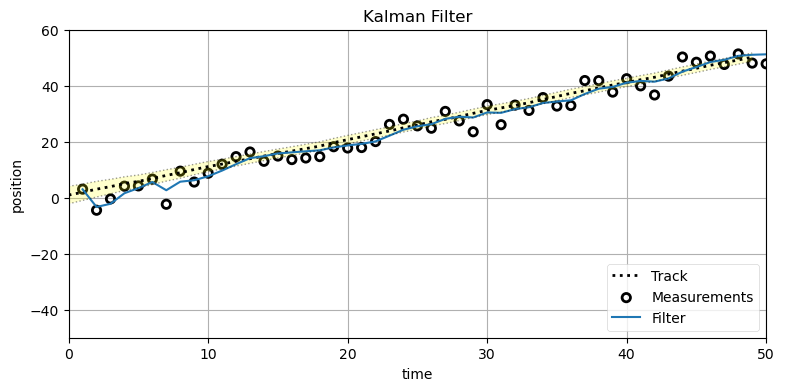

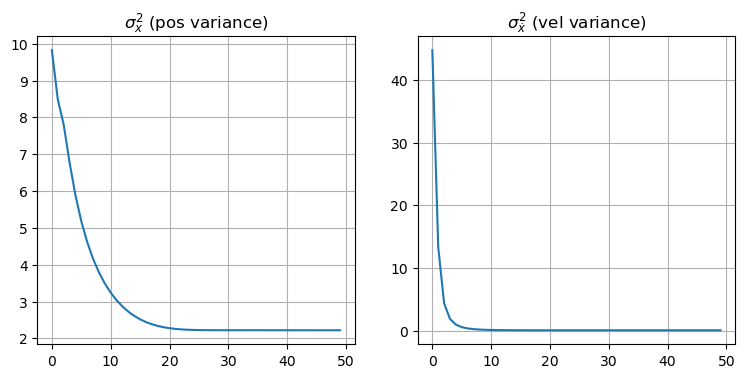

In [30]:
P = np.diag([500., 49.])
Ms, Ps = run(count=50, R=10, Q=0.01, P=P)

There is still a lot to learn, but we have implemented a Kalman filter using the same theory and equations as published by Rudolf Kalman! Code very much like this runs inside of your GPS, airliners, robots, and so on. 

还有许多内容需要学习，但我们已经使用鲁道夫·卡尔曼发表的同一套理论和方程实现了一个卡尔曼滤波器！与你这里的代码非常相似的代码正运行在 GPS、客机、机器人等设备中。

The first plot plots the output of the Kalman filter against the measurements and the actual position of our dog (labelled *Track*). After the initial settling in period the filter should track the dog's position very closely. The yellow shaded portion between the black dotted lines shows 1 standard deviations of the filter's variance, which I explain in the next paragraph.

第一幅图将卡尔曼滤波器输出与测量值以及狗的实际位置进行对比，实际位置标为 *Track*。经过初始稳定阶段后，滤波器应当能够非常紧密地跟踪狗的位置。黑色虚线之间的黄色阴影部分表示滤波器方差的 1 个标准差，下一段会对此加以说明。

The next two plots show the variance of $x$ and of $\dot x$. I have plotted the diagonals of $\mathbf P$ over time. Recall that the diagonal of a covariance matrix contains the variance of each state variable. So $\mathbf P[0,0]$ is the variance of $x$, and $\mathbf P[1,1]$ is the variance of $\dot x$. You can see that we quickly converge to small variances for both. 

接下来的两幅图显示 $x$ 和 $\dot x$ 的方差。我绘制了 $\mathbf P$ 的对角元素随时间的变化。请回忆，协方差矩阵的对角线包含各状态变量的方差。因此，$\mathbf P[0,0]$ 是 $x$ 的方差，$\mathbf P[1,1]$ 是 $\dot x$ 的方差。可以看到，两者都很快收敛到较小的方差。

The covariance matrix $\mathbf P$ tells us the *theoretical* performance of the filter *assuming* everything we tell it is true. Recall that the standard deviation is the square root of the variance, and that approximately 68% of a Gaussian distribution occurs within one standard deviation. If at least 68% of the filter output is within one standard deviation  the filter may be performing well. In the top chart I have displayed the one standard deviation as the yellow shaded area between the two dotted lines. To my eye it looks like perhaps the filter is slightly exceeding that bounds, so the filter probably needs some tuning.

协方差矩阵 $\mathbf P$ 告诉我们，在*假定*我们提供给它的一切都正确时，滤波器的*理论*性能。请回忆，标准差是方差的平方根，且高斯分布中约有 68% 的概率落在一个标准差以内。如果至少有 68% 的滤波器输出位于一个标准差以内，滤波器的表现可能良好。在上图中，我用两条虚线之间的黄色阴影区域表示一个标准差。依我看，滤波器似乎略微超出了该范围，因此可能需要进行一些调参。

In the univariate chapter we filtered very noisy signals with much simpler code than the code above. However, realize that right now we are working with a very simple example - an object moving through 1-D space and one sensor. That is about the limit of what we can compute with the code in the last chapter. In contrast, we can implement very complicated, multidimensional filters with this code merely by altering our assignments to the filter's variables. Perhaps we want to track 100 dimensions in financial models. Or we have an aircraft with a GPS, INS, TACAN, radar altimeter, baro altimeter, and airspeed indicator, and we want to integrate all those sensors into a model that predicts position, velocity, and acceleration in 3D space. We can do that with the code in this chapter.

在单变量章节中，我们用比上面简单得多的代码滤除了噪声极大的信号。但是要认识到，我们现在处理的是一个非常简单的例子，一个在一维空间中运动的物体和一个传感器。这大致就是上一章代码所能计算的极限。相比之下，只需改变对滤波器变量的赋值，就能用本章的代码实现非常复杂的多维滤波器。也许我们想在金融模型中跟踪 100 个维度。或者，我们有一架装有 GPS、INS、TACAN、雷达高度计、气压高度计和空速指示器的飞机，并希望将所有这些传感器整合到一个预测三维空间中位置、速度和加速度的模型中。我们可以用本章的代码做到这一点。

I want you to get a better feel for how the Gaussians change over time, so here is a 3D plot showing the Gaussians every 7th epoch (time step). Every 7th separates them enough so can see each one independently. The first Gaussian at $t=0$ is to the left.

我希望你能更好地感受高斯分布如何随时间变化，因此这里有一张三维图，展示每隔 7 个时刻的高斯分布。每隔 7 个时刻绘制一次，能使它们分开得足够远，从而可以分别观察。$t=0$ 时的第一个高斯分布位于左侧。


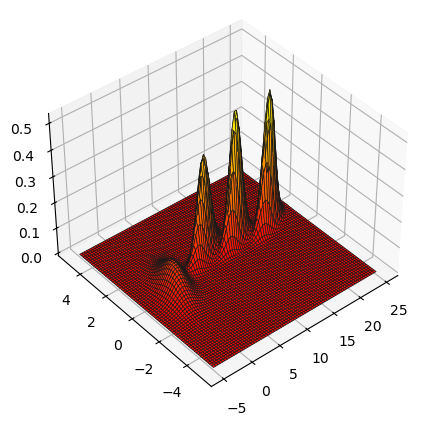

In [31]:
from kf_book.book_plots import set_figsize, figsize
from kf_book.nonlinear_plots import plot_gaussians

P = np.diag([3., 1.])
np.random.seed(3)
Ms, Ps = run(count=25, R=10, Q=0.01, P=P, do_plot=False)
with figsize(x=9, y=5):
    plot_gaussians(Ms[::7], Ps[::7], (-5,25), (-5, 5), 75)

## The Saver Class
## Saver 类

In the `run()` method I wrote boilerplate code to save the results of the filter

在 `run()` 方法中，我编写了用于保存滤波器结果的样板代码

```python
    xs, cov = [], []
    for z in zs:
        kf.predict()
        kf.update(z)
        xs.append(kf.x)
        cov.append(kf.P)

    xs, cov = np.array(xs), np.array(cov)
```

There's an easy way to avoid this. `filterpy.common` provides the `Saver` class which will save all attributes in the Kalman filter class each time `Saver.save()` is called. Let's see it in action and then we will talk about it more.

有一种简单的方法可以避免这样做。`filterpy.common` 提供了 `Saver` 类，每次调用 `Saver.save()` 时，它都会保存卡尔曼滤波器类中的所有属性。让我们先看看它如何工作，然后再详细讨论。


In [32]:
from filterpy.common import Saver
kf = pos_vel_filter([0, .1], R=R, P=P, Q=Q, dt=1.) 
s = Saver(kf)
for i in range(1, 6):
    kf.predict()
    kf.update([i])
    s.save()  # save the current state

The `Saver` object now contains lists of all the attributes of the KalmanFilter object. `kf.x` is the current state estimate of the filter. Therefore `s.x` contains the saved state estimate that was computed inside the loop:

`Saver` 对象现在包含 `KalmanFilter` 对象全部属性的列表。`kf.x` 是滤波器当前的状态估计。因此，`s.x` 包含在循环内部计算并保存的状态估计：


In [33]:
s.x

[array([0.531, 0.304]),
 array([1.555, 0.763]),
 array([2.784, 1.036]),
 array([3.944, 1.105]),
 array([5.015, 1.086])]

You can see all the available attributes with the `keys` attribute:

通过 `keys` 属性可以查看所有可用的属性：


In [34]:
s.keys

['alpha',
 'likelihood',
 'log_likelihood',
 'mahalanobis',
 'dim_x',
 'dim_z',
 'dim_u',
 'x',
 'P',
 'Q',
 'B',
 'F',
 'H',
 'R',
 '_alpha_sq',
 'M',
 'z',
 'K',
 'y',
 'S',
 'SI',
 '_I',
 'x_prior',
 'P_prior',
 'x_post',
 'P_post',
 '_log_likelihood',
 '_likelihood',
 '_mahalanobis',
 'inv']

There are many attributes there that we haven't discussed yet, but many should be familar.

其中有许多我们尚未讨论过的属性，但很多应该已经很熟悉了。

At this point you could write code to plot any of these variables. However, it is often more useful to use `np.array` instead of lists. Calling `Saver.to_array()` will convert the lists into `np.array`. There is one caveat: if the shape of any of the attributes changes during the run, the `to_array` will raise an exception since `np.array` requires all of the elements to be of the same type and size. 

此时，你可以编写代码来绘制其中任意变量。不过，使用 `np.array` 通常比使用列表更方便。调用 `Saver.to_array()` 会将列表转换为 `np.array`。但有一个注意事项：如果运行期间任一属性的形状发生变化，`to_array` 会引发异常，因为 `np.array` 要求所有元素具有相同的类型和大小。

If you look at the keys again you'll see that `z` is one of the choices. This is promising; apparently the measurement `z` is saved for us. Let's plot it against the estimate.

再次查看这些键，你会发现 `z` 是其中一个选项。这很有希望，显然测量值 `z` 已为我们保存。让我们将它与估计值绘制在一起。


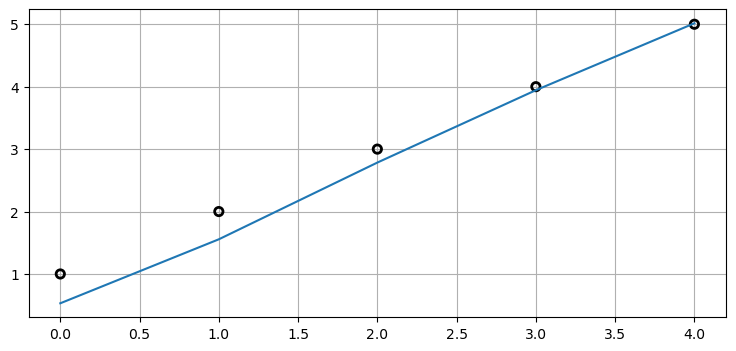

In [35]:
import matplotlib.pyplot as plt

s.to_array()
book_plots.plot_measurements(s.z);
plt.plot(s.x[:, 0]);

While I've demonstrated this with the `KalmanFilter` class, it will work with all filter classes implemented by `FilterPy`. It will probably work with any class you write as well, as it inspects the object to retrieve the attribute names. We will use this class throughout the book to keep the code readable and short. Using the `Saver` will slow down your code because a lot happens behind the scenes, but for learning and exploring the convience cannot be beat.

虽然我用 `KalmanFilter` 类演示了这一点，但它适用于 `FilterPy` 实现的所有滤波器类。它很可能也适用于你编写的任何类，因为它会检查对象以获取属性名称。全书都会使用这个类，以保持代码简洁易读。使用 `Saver` 会减慢代码运行速度，因为后台会执行许多操作，但对于学习和探索而言，它的便利性无可替代。


## The Kalman Filter Equations
## 卡尔曼滤波器方程

We are now ready to learn how `predict()` and `update()` perform their computations. 

现在，我们已准备好了解 `predict()` 和 `update()` 如何执行计算。

A word about notation. I'm a programmer, and I am used to code that reads

先说一下记法。我是一名程序员，习惯于下面这样的代码：

```python
x = x + 1
``` 

That is not an equation as the sides are not equal, but an *assignment*. If we wanted to write this in mathematical notation we'd write

这不是一个方程，因为等式两边并不相等，而是一条*赋值*语句。若要用数学记法表达它，我们会写成

$$x_k = x_{k-1} + 1$$

Kalman filter equations are littered with subscripts and superscripts to keep the equations mathematically consistent. I find this makes them extremely hard to read. In most of the book I opt for subscriptless assignments. As a programmer you should understand that I am showing you assignments which implement an algorithm that is to be executed step by step. I'll elaborate on this once we have a concrete example.

为保持数学上的一致性，卡尔曼滤波器方程中充满了下标和上标。我认为这使它们极难阅读。本书的大部分内容会采用不带下标的赋值形式。作为程序员，你应当理解，我展示的是实现某个算法的赋值语句，该算法需要逐步执行。等有了具体示例后，我会进一步说明这一点。


### Prediction Equations
### 预测方程

The Kalman filter uses these equations to compute the *prior* - the predicted next state of the system. They compute the prior mean ($\bar{\mathbf x}$)  and covariance ($\bar{\mathbf P}$) of the system.

卡尔曼滤波器使用这些方程计算*先验*，即系统预测的下一状态。它们计算系统的先验均值（$\bar{\mathbf x}$）和协方差（$\bar{\mathbf P}$）。

$$\begin{aligned}
\mathbf{\bar x} &= \mathbf{Fx} + \mathbf{Bu}\\
\mathbf{\bar P} &= \mathbf{FPF}^\mathsf T + \mathbf Q
\end{aligned}$$

$\underline{\textbf{Mean}}$

均值

$\mathbf{\bar x} = \mathbf{Fx} + \mathbf{Bu}$

As a reminder, the linear equation $\mathbf{Ax} = \mathbf b$ represents a system of equations, where $\mathbf A$ holds the coefficients set of equations, $\mathbf x$ is the vector of variables. Performing the multiplication $\mathbf{Ax}$ computes the right hand side values for that set of equations, represented by $\mathbf b$.

提醒一下，线性方程 $\mathbf{Ax} = \mathbf b$ 表示一个方程组，其中 $\mathbf A$ 包含方程组的系数，$\mathbf x$ 是变量向量。执行乘法 $\mathbf{Ax}$ 会计算该方程组右侧的值，即由 $\mathbf b$ 表示的值。

If $\mathbf F$ contains the state transition for a given time step, then the product $\mathbf{Fx}$ computes the state after that transition. Easy! Likewise, $\mathbf B$ is the control function, $\mathbf u$ is the control input, so $\mathbf{Bu}$ computes the contribution of the controls to the state after the transition. Thus, the prior $\mathbf{\bar x}$ is computed as the sum of $\mathbf{Fx}$ and $\mathbf{Bu}$.

如果 $\mathbf F$ 包含给定时间步的状态转移，那么乘积 $\mathbf{Fx}$ 就会计算该转移之后的状态。很简单！同样，$\mathbf B$ 是控制函数，$\mathbf u$ 是控制输入，因此 $\mathbf{Bu}$ 计算控制量对转移后状态的贡献。于是，先验 $\mathbf{\bar x}$ 就是 $\mathbf{Fx}$ 与 $\mathbf{Bu}$ 之和。

The equivalent univariate equation is

等价的单变量方程为

$$\bar\mu = \mu + \mu_{move}$$

If you perform the matrix multiplication $\mathbf{Fx}$ it generates this equation for $x$.

执行矩阵乘法 $\mathbf{Fx}$，就会得到关于 $x$ 的这个方程。

Let's make this explicit. Recall the value for $\mathbf F$ from the last chapter:

让我们把它明确写出来。回忆上一章中 $\mathbf F$ 的值：

$$\mathbf F = \begin{bmatrix}1&\Delta t  \\ 0&1\end{bmatrix}$$

Thus $\mathbf{\bar x} = \mathbf{Fx}$ corresponds to the set of linear equations:

因此，$\mathbf{\bar x} = \mathbf{Fx}$ 对应以下线性方程组：

$$\begin{cases}
\begin{aligned}
\bar x &= 1x + &\Delta t\, \dot x \\
\bar{\dot x} &=0x + &1\, \dot x
\end{aligned}
\end{cases}$$


$\underline{\textbf{Covariance}}$

协方差

$\mathbf{\bar P} = \mathbf{FPF}^\mathsf T + \mathbf Q$

This equation is not as easy to understand so we will spend more time on it. 

这个方程不那么容易理解，因此我们会花更多时间来讨论它。

In univariate version of this equation is:

该方程的单变量形式为：

$$\bar\sigma^2 = \sigma^2 + \sigma^2_{move}$$

We add the variance of the movement to the variance of our estimate to reflect the loss of knowlege. We need to do the same thing here, except it isn't quite that easy with multivariate Gaussians. 

我们将运动的方差加到估计值的方差上，以反映知识的损失。这里也需要做同样的事，只是在多元高斯分布中没有这么简单。

We can't simply write $\mathbf{\bar P} = \mathbf P + \mathbf Q$. In a multivariate Gaussians the state variables are *correlated*. What does this imply? Our knowledge of the velocity is imperfect, but we are adding it to the position with

我们不能简单地写成 $\mathbf{\bar P} = \mathbf P + \mathbf Q$。在多元高斯分布中，状态变量是*相关的*。这意味着什么？我们对速度的了解并不精确，但要通过下式将它加到位置上：

$$\bar x = \dot x\Delta t + x$$

Since we do not have perfect knowledge of the value of $\dot x$ the sum $\bar x = \dot x\Delta t + x$ gains uncertainty. Because the positions and velocities are correlated we cannot simply add the covariance matrices. For example, if $\mathbf P$ and $\mathbf Q$ are diagonal matrices the sum would also be diagonal. But we know position is correlated to velocity so the off-diagonal elements should be non-zero. 

由于我们并不完全知道 $\dot x$ 的值，和 $\bar x = \dot x\Delta t + x$ 会获得不确定性。由于位置和速度相关，我们不能简单地将协方差矩阵相加。例如，若 $\mathbf P$ 和 $\mathbf Q$ 是对角矩阵，它们的和也将是对角矩阵。但我们知道位置与速度相关，因此非对角元素应当非零。

The correct equation is

正确的方程是

$$\mathbf{\bar P} = \mathbf{FPF}^\mathsf T + \mathbf Q$$

Expressions in the form $\mathbf{ABA}^\mathsf T$ are common in linear algebra. You can think of it as *projecting* the middle term by the outer term. We will be using this many times in the rest of the book. I admit this may be a 'magical' equation to you. Let's explore it.

形如 $\mathbf{ABA}^\mathsf T$ 的表达式在线性代数中很常见。你可以将它视为用外侧项对中间项进行*投影*。在本书余下的内容中，我们会多次使用它。我承认，这个方程对你来说可能有些“神奇”。让我们探究一下。

When we initialize $\mathbf P$ with

当我们用下式初始化 $\mathbf P$ 时

$$\mathbf P = \begin{bmatrix}\sigma^2_x & 0 \\ 0 & \sigma^2_v\end{bmatrix}$$


the value for $\mathbf{FPF}^\mathsf T$ is:

$\mathbf{FPF}^\mathsf T$ 的值为：

$$\begin{aligned}
\mathbf{FPF}^\mathsf T &= \begin{bmatrix}1&\Delta t\\0&1\end{bmatrix}
\begin{bmatrix}\sigma^2_x & 0 \\  0 & \sigma^2_{v}\end{bmatrix}
\begin{bmatrix}1&0\\\Delta t&1\end{bmatrix} \\
&= \begin{bmatrix}\sigma^2_x&\sigma_v^2\Delta t\\  0 & \sigma^2_{v}\end{bmatrix}
\begin{bmatrix}1&0\\\Delta t&1\end{bmatrix} \\
&= \begin{bmatrix}\sigma^2_x +  \sigma_v^2\Delta t^2  &  \sigma_v^2\Delta t \\
\sigma_v^2\Delta t & \sigma^2_{v}\end{bmatrix}
\end{aligned}$$

The initial value for $\mathbf P$ had no covariance between the position and velocity.  Position is computed as $\dot x\Delta t + x$, so there is a correlation between the position and velocity. The multiplication $\mathbf{FPF}^\mathsf T$ computes a covariance of $\sigma_v^2 \Delta t$. The exact value is not important; you just need to recognize that $\mathbf{FPF}^\mathsf T$ uses the process model to automatically compute the covariance between the position and velocity!

$\mathbf P$ 的初始值中，位置和速度之间没有协方差。位置计算为 $\dot x\Delta t + x$，因此位置和速度之间存在相关性。乘法 $\mathbf{FPF}^\mathsf T$ 会计算出 $\sigma_v^2 \Delta t$ 这一协方差。确切数值并不重要，你只需要认识到，$\mathbf{FPF}^\mathsf T$ 使用过程模型自动计算位置和速度之间的协方差！

Another way to think of this is to reflect on the $\mathbf{Fx}$ multiplication. That projected $\mathbf x$ forward in time. $\mathbf {FP}$ might seem to be the equivalent operation, but $\mathbf P$ is a matrix while $\mathbf x$ is a vector. The trailing $\mathbf F^\mathsf T$ term ensures that we multiply by both the rows and columns of $\mathbf F$. In the second line of the computation of $\mathbf{FPF}^\mathsf T$ we have the value for $\mathbf{FP}$. You can see that it is an upper triangular matrix because we haven't fully incorporated $\mathbf F$ into the multiplication.

另一种理解方式是回顾 $\mathbf{Fx}$ 乘法。它将 $\mathbf x$ 在时间上向前投影。$\mathbf {FP}$ 看起来可能是等价操作，但 $\mathbf P$ 是矩阵，而 $\mathbf x$ 是向量。末尾的 $\mathbf F^\mathsf T$ 项确保我们同时乘以 $\mathbf F$ 的行和列。在计算 $\mathbf{FPF}^\mathsf T$ 的第二行中，得到的是 $\mathbf{FP}$ 的值。可以看到，它是一个上三角矩阵，因为我们尚未将 $\mathbf F$ 完全纳入乘法。

If you have some experience with linear algebra and statistics, this may help. The covariance due to the prediction can be modeled as the expected value of the error in the prediction step, given by this equation. 

如果你具备一些线性代数和统计学经验，下面的内容可能会有所帮助。预测所导致的协方差可以建模为预测步骤中误差的期望值，如下式所示。

$$\begin{aligned}
\bar{\mathbf P} &= \mathbb E[(\mathbf{Fx - F\bar \mu})(\mathbf{Fx - F\bar\mu})^\mathsf T]\\
 &= \mathbf F\, \mathbb E[\mathbf{(x- \bar\mu)(x- \bar\mu)}^\mathsf T]\, \mathbf F^\mathsf T
\end{aligned}$$

Of course, $\mathbb E[\mathbf{(x- \bar\mu)(x- \bar\mu)}^\mathsf T]$ is just $\mathbf P$, giving us

当然，$\mathbb E[\mathbf{(x- \bar\mu)(x- \bar\mu)}^\mathsf T]$ 正是 $\mathbf P$，因此得到

$$\bar{\mathbf P} = \mathbf{FPF}^\mathsf T$$

Let's look at its effect. Here I use $\mathbf F$ from our filter and project the state forward 6/10ths of a second. I do this five times so you can see how $\mathbf{\bar P}$ continues to change. 

让我们看看它的效果。这里我使用滤波器中的 $\mathbf F$，将状态向前投影 6/10 秒。我重复五次，以便你看到 $\mathbf{\bar P}$ 如何持续变化。


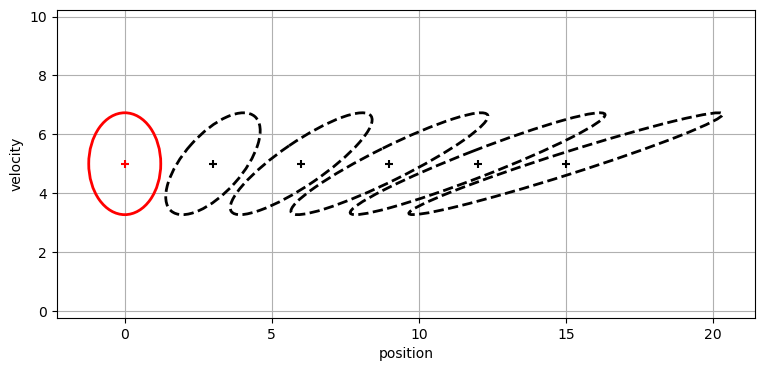

In [36]:
dt = 0.6
x = np.array([0., 5.])
F = np.array([[1., dt], [0, 1.]])
P = np.array([[1.5, 0], [0, 3.]])
plot_covariance_ellipse(x, P, edgecolor='r')

for _ in range(5):
    x = np.dot(F, x)
    P = np.dot(F, P).dot(F.T)
    plot_covariance_ellipse(x, P, edgecolor='k', ls='dashed')
book_plots.set_labels(x='position', y='velocity')

You can see that with a velocity of 5 the position correctly moves 3 units in each 6/10ths of a second step. At each step the width of the ellipse is larger, indicating that we have lost information about the position due to adding $\dot x\Delta t$ to x at each step. The height has not changed - our system model says the velocity does not change, so the belief we have about the velocity cannot change. As time continues you can see that the ellipse becomes more and more tilted. Recall that a tilt indicates *correlation*. $\mathbf F$ linearly correlates $x$ with $\dot x$ with the expression $\bar x = \dot x \Delta t + x$. The $\mathbf{FPF}^\mathsf T$ computation correctly incorporates this correlation into the covariance matrix.

可以看到，当速度为 5 时，位置在每个 6/10 秒的时间步中都会正确移动 3 个单位。每一步中，椭圆的宽度都会增大，这表明由于每一步都将 $\dot x\Delta t$ 加到 $x$ 上，我们丢失了关于位置的信息。椭圆的高度没有变化，因为系统模型表明速度不变，所以我们对速度的信念不会改变。随着时间推移，椭圆会越来越倾斜。回忆一下，倾斜表示*相关性*。$\mathbf F$ 通过表达式 $\bar x = \dot x \Delta t + x$ 在线性上将 $x$ 与 $\dot x$ 相关联。$\mathbf{FPF}^\mathsf T$ 的计算会正确地将这种相关性纳入协方差矩阵。

Here is an animation of this equation that allows you to change the design of $\mathbf F$ to see how it affects shape of $\mathbf P$. The `F00` slider affects the value of F[0, 0]. `covar` sets the intial covariance between the position and velocity($\sigma_x\sigma_{\dot x}$). I recommend answering these questions at a minimum

下面是该方程的动画，你可以改变 $\mathbf F$ 的设计，观察它如何影响 $\mathbf P$ 的形状。`F00` 滑块影响 F[0, 0] 的值。`covar` 设置位置与速度之间的初始协方差（$\sigma_x\sigma_{\dot x}$）。至少建议回答以下问题：

* what if $x$ is not correlated to $\dot x$? (set F01 to 0, the rest at defaults)
* what if $x = 2\dot x\Delta t + x_0$? (set F01 to 2, the rest at defaults)
* what if $x = \dot x\Delta t + 2x_0$? (set F00 to 2, the rest at defaults)
* what if $x = \dot x\Delta t$?  (set F00 to 0, the rest at defaults)

* 如果 $x$ 与 $\dot x$ 不相关，会怎样？（将 F01 设为 0，其余保持默认值）
* 如果 $x = 2\dot x\Delta t + x_0$，会怎样？（将 F01 设为 2，其余保持默认值）
* 如果 $x = \dot x\Delta t + 2x_0$，会怎样？（将 F00 设为 2，其余保持默认值）
* 如果 $x = \dot x\Delta t$，会怎样？（将 F00 设为 0，其余保持默认值）


interactive(children=(IntSlider(value=1, continuous_update=False, description='F00', max=2), FloatSlider(value…

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


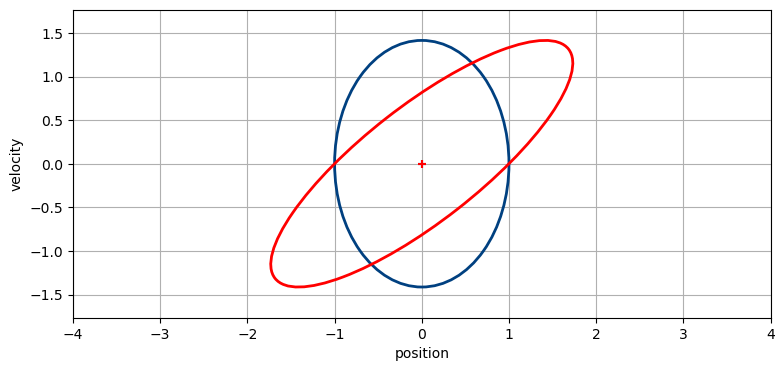

In [37]:
from ipywidgets import interact
from kf_book.book_plots import IntSlider, FloatSlider

def plot_FPFT(F00, F01, F10, F11, covar):   
    plt.figure()
    dt = 1.
    x = np.array((0, 0.))
    P = np.array(((1, covar), (covar, 2)))
    F = np.array(((F00, F01), (F10, F11)))
    plot_covariance_ellipse(x, P)
    plot_covariance_ellipse(x, np.dot(F, P).dot(F.T), ec='r')
    plt.gca().set_aspect('equal')
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)
    #plt.title(str(F))
    plt.xlabel('position')
    plt.ylabel('velocity')
                 
interact(plot_FPFT, 
         F00=IntSlider(value=1, min=0, max=2), 
         F01=FloatSlider(value=1, min=0, max=2, description='F01(dt)'),
         F10=FloatSlider(value=0, min=0, max=2),
         F11=FloatSlider(value=1, min=0, max=2),
         covar=FloatSlider(value=0, min=0, max=1));

(If you are reading this in a static form: instructions to run this online are here: https://git.io/vza7b). Or, go to binder using the link below, and open this notebook from there.

（如果你正在以静态形式阅读本书，在线运行说明见此处：https://git.io/vza7b。）或者，使用下面的链接进入 binder，并从那里打开此笔记本。

http://mybinder.org/repo/rlabbe/Kalman-and-Bayesian-Filters-in-Python


### Update Equations
### 更新方程

The update equations look messier than the predict equations, but that is mostly due to the Kalman filter computing the update in measurement space. This is because measurements are not *invertible*. For example, consider a  sensor that gives the range to a target. It is impossible to convert a range into a position - an infinite number of positions in a circle will yield the same range. On the other hand, we can always compute the range (measurement) given a position (state).

更新方程看起来比预测方程更复杂，但这主要是因为卡尔曼滤波器在测量空间中计算更新。这是因为测量是*不可逆的*。例如，考虑一个给出目标距离的传感器。不可能将一个距离转换为一个位置，因为圆周上无穷多个位置都会得到相同的距离。另一方面，给定一个位置（状态），我们总能计算出距离（测量值）。

Before I continue, recall that we are trying to do something very simple: choose a new estimate chosen somewhere between a measurement and a prediction, as in this chart:

继续之前，请回忆一下，我们试图做的是一件很简单的事：如图所示，在测量值与预测值之间选择一个新的估计值：

<img src="./figs/residual_chart.png">


The equations will be complicated because the state has multiple dimensions, but this operations is what we are doing. Don't let the equations distract you from the simplicity of this idea.

由于状态具有多个维度，方程会比较复杂，但我们所做的操作就是这些。不要让方程掩盖了这个思想本身的简单性。

$\underline{\textbf{System Uncertainty}}$

系统不确定性

$\textbf{S} = \mathbf{H\bar PH}^\mathsf T + \mathbf R$

To work in measurement space the Kalman filter has to project the covariance matrix into measurement space. The math for this is $\mathbf{H\bar PH}^\mathsf T$, where $\mathbf{\bar P}$ is the *prior* covariance and $\mathbf H$ is the measurement function.

为了在测量空间中工作，卡尔曼滤波器必须将协方差矩阵投影到测量空间。其数学表达为 $\mathbf{H\bar PH}^\mathsf T$，其中 $\mathbf{\bar P}$ 是*先验*协方差，$\mathbf H$ 是测量函数。

You should recognize this $\mathbf{ABA}^\mathsf T$ form - the prediction step used $\mathbf{FPF}^\mathsf T$ to update $\mathbf P$ with the state transition function. Here, we use the same form to update it with the measurement function. The linear algebra is changing the coordinate system for us. 

你应该能认出这种 $\mathbf{ABA}^\mathsf T$ 形式，预测步骤使用 $\mathbf{FPF}^\mathsf T$ 通过状态转移函数更新 $\mathbf P$。这里，我们使用相同的形式通过测量函数进行更新。线性代数为我们完成了坐标系的转换。

Once the covariance is in measurement space we need to account for the sensor noise. This is very easy  - we just add matrices. The result is variously called the *system uncertainty* or *innovation covariance*.

协方差进入测量空间后，我们还需要考虑传感器噪声。这很容易，只需将矩阵相加。所得结果也称为*系统不确定性*或*预测/更新协方差*。

If you ignore the $\mathbf H$ term this equation is the equivalent to the denominator in the univariate equation for the Kalman gain:

如果忽略 $\mathbf H$ 项，这个方程等价于单变量卡尔曼增益方程中的分母：

$$K = \frac {\bar\sigma^2} {\bar\sigma^2 + \sigma_z^2}$$

Compare the equations for the system uncertainty and the covariance

比较系统不确定性和协方差的方程：

$$\begin{aligned}
\mathbf{S} &= \mathbf{H\bar PH}^\mathsf T + \mathbf R\\
\mathbf{\bar P} &= \mathbf{FPF}^\mathsf T + \mathbf Q
\end{aligned}$$

In each equation $\mathbf P$ is put into a different space with either the function $\mathbf H$ or $\mathbf F$. Then we add the noise matrix associated with that space.

在每个方程中，$\mathbf P$ 都通过函数 $\mathbf H$ 或 $\mathbf F$ 被置入不同的空间。随后，我们加上与该空间相关的噪声矩阵。

$\underline{\textbf{Kalman Gain}}$

卡尔曼增益

$\mathbf K = \mathbf{\bar PH}^\mathsf T \mathbf{S}^{-1}$

Look back at the residual diagram. Once we have a prediction and a measurement we need to select an estimate somewhere between the two. If we have more certainty about the measurement the estimate will be closer to it. If instead we have more certainty about the prediction then the estimate will be closer to it. 

回看残差图。一旦有了预测和测量，我们就需要在两者之间选择一个估计。如果我们对测量更有把握，估计就会更接近测量。反之，如果我们对预测更有把握，估计就会更接近预测。

In the univariate chapter we scaled the mean using this equation

在单变量章节中，我们使用下式对均值进行加权：

$$
\mu =\frac{\bar\sigma^2 \mu_z + \sigma_\mathtt{z}^2 \bar\mu} {\bar\sigma^2 + \sigma_\mathtt{z}^2}$$

which we simplified to

我们将其简化为：

$$\mu = (1-K)\bar\mu + K\mu_\mathtt{z}$$

which gave us

由此得到：

$$K = \frac {\bar\sigma^2} {\bar\sigma^2 + \sigma_z^2}$$

$K$ is the *Kalman gain*, and it is a real number between 0 and 1. Ensure you understand how it selects a mean somewhere between the prediction and measurement. The Kalman gain is a *percentage* or *ratio* - if K is .9 it takes 90% of the measurement and 10% of the prediction. 

$K$ 是*卡尔曼增益*，它是介于 0 和 1 之间的实数。请确保你理解它如何在预测和测量之间选择一个均值。卡尔曼增益是一个*百分比*或*比率*，如果 K 为 .9，它就取测量的 90% 和预测的 10%。

For the multivariate Kalman filter $\mathbf K$ is a vector, not a scalar. Here is the equation again: $\mathbf K = \mathbf{\bar PH}^\mathsf T \mathbf{S}^{-1}$. Is this a *ratio*? We can think of the inverse of a matrix as linear algebra's way of finding the reciprocal. Division is not defined for matrices, but it is useful to think of it in this way. So we can read the equation for $\textbf{K}$ as meaning

对于多元卡尔曼滤波器，$\mathbf K$ 是向量，而不是标量。再看一遍方程：$\mathbf K = \mathbf{\bar PH}^\mathsf T \mathbf{S}^{-1}$。它是一个*比率*吗？我们可以把矩阵的逆看作线性代数中求倒数的方式。矩阵并未定义除法，但这样理解是有帮助的。因此，我们可以将 $\textbf{K}$ 的方程理解为：

$$\begin{aligned} \mathbf K &\approx \frac{\mathbf{\bar P}\mathbf H^\mathsf T}{\mathbf{S}} \\
\mathbf K &\approx \frac{\mathsf{uncertainty}_\mathsf{prediction}}{\mathsf{uncertainty}_\mathsf{measurement}}\mathbf H^\mathsf T
\end{aligned}$$

The Kalman gain equation computes a ratio based on how much we trust the prediction vs the measurement. We did the same thing in every prior chapter. The equation is complicated because we are doing this in multiple dimensions via matrices, but the concept is simple. The $\mathbf H^\mathsf T$ term is less clear, I'll explain it soon. If you ignore that term the equation for the Kalman gain is the same as the univariate case: divide the uncertainty of the prior with the of the sum of the uncertainty of the prior and measurement.

卡尔曼增益方程根据我们对预测和测量的信任程度计算一个比率。此前每一章我们做的都是同一件事。这个方程之所以复杂，是因为我们通过矩阵在多个维度中完成它，但概念很简单。$\mathbf H^\mathsf T$ 项不太直观，我很快会解释它。若忽略该项，卡尔曼增益方程就与单变量情形相同：用先验的不确定性除以先验不确定性与测量不确定性之和。

$\underline{\textbf{Residual}}$

残差

$\mathbf y = \mathbf z - \mathbf{H\bar{x}}$

This is an easy one as we've covered this equation while designing the measurement function $\mathbf H$. Recall that the measurement function converts a state into a measurement. So $\mathbf{Hx}$ converts $\mathbf x$ into an equivalent measurement. Once that is done, we can subtract it from the measurement $\mathbf z$ to get the residual - the difference between the measurement and prediction.

这一项很简单，因为我们在设计测量函数 $\mathbf H$ 时已经讲过这个方程。回忆一下，测量函数会将状态转换为测量。因此，$\mathbf{Hx}$ 将 $\mathbf x$ 转换为等价的测量。完成这一步后，我们可以用测量 $\mathbf z$ 减去它，得到残差，也就是测量与预测之间的差。

The univariate equation is

单变量方程为：

$$y = z - \bar x$$

and clearly computes the same thing, but only in one dimension.

它显然计算的是同一件事，只不过是在一个维度中。

$\underline{\textbf{State Update}}$

状态更新

$\mathbf x = \mathbf{\bar x} + \mathbf{Ky}$

We select our new state to be along the residual, scaled by the Kalman gain. The scaling is performed by $\mathbf{Ky}$, which both scales the residual and converts it back into state space with the $\mathbf H^\mathsf T$ term which is in $\mathbf K$. This is added to the prior, yielding the equation: $\mathbf x =\mathbf{\bar x} + \mathbf{Ky}$. Let me write out $\mathbf K$ so we can see the entire computation:

我们选择沿残差方向的新状态，并由卡尔曼增益对其缩放。缩放由 $\mathbf{Ky}$ 完成，它既会缩放残差，也会借助 $\mathbf K$ 中的 $\mathbf H^\mathsf T$ 项将残差转换回状态空间。再将其加到先验上，便得到方程：$\mathbf x =\mathbf{\bar x} + \mathbf{Ky}$。将 $\mathbf K$ 展开，就能看到完整的计算过程：

$$\begin{aligned}
\mathbf x &= \mathbf{\bar x} + \mathbf{Ky} \\
&= \mathbf{\bar x} + \mathbf{\bar PH}^\mathsf T \mathbf{S}^{-1}\mathbf y \\
&\approx \mathbf{\bar x} + \frac{\mathsf{uncertainty}_\mathsf{prediction}}{\mathsf{uncertainty}_\mathsf{measurement}}\mathbf H^\mathsf T \mathbf y
\end{aligned}$$

Perhaps a better way to *see* the ratio is to rewrite the estimate equation:

要更好地*看出*这个比率，或许可以改写估计方程：

$$\begin{aligned}
\mathbf x &= \mathbf{\bar x} + \mathbf{Ky} \\
&= \mathbf{\bar x} +\mathbf K(\mathbf z - \mathbf{H\bar x}) \\
&= (\mathbf I - \mathbf{KH})\mathbf{\bar x} + \mathbf{Kz}
\end{aligned}$$

The similarity between this and the univariate form should be obvious:

它与单变量形式之间的相似性应当很明显：

$$\mu = (1-K)\bar\mu + K\mu_\mathtt{z}$$

$\underline{\textbf{Covariance Update}}$

协方差更新

$\mathbf P = (\mathbf{I}-\mathbf{KH})\mathbf{\bar P}$

$\mathbf{I}$ is the identity matrix, and is the way we represent $1$ in multiple dimensions. $\mathbf H$ is our measurement function, and is a constant.  We can think of the equation as $\mathbf P = (1-c\mathbf K)\mathbf P$. $\mathbf K$ is our ratio of how much prediction vs measurement we use. If $\mathbf K$ is large then $(1-\mathbf{cK})$ is small, and $\mathbf P$ will be made smaller than it was. If $\mathbf K$ is small, then $(1-\mathbf{cK})$ is large, and $\mathbf P$ will be relatively larger. This means that we adjust the size of our uncertainty by some factor of the Kalman gain.

$\mathbf{I}$ 是单位矩阵，它是在多个维度中表示 $1$ 的方式。$\mathbf H$ 是我们的测量函数，且为常数。我们可以将该方程理解为 $\mathbf P = (1-c\mathbf K)\mathbf P$。$\mathbf K$ 表示我们使用预测与测量的比例。如果 $\mathbf K$ 很大，则 $(1-\mathbf{cK})$ 很小，$\mathbf P$ 会比原来更小。如果 $\mathbf K$ 很小，则 $(1-\mathbf{cK})$ 很大，$\mathbf P$ 会相对更大。这意味着，我们通过卡尔曼增益的某个因子来调整不确定性的大小。

This equation can be numerically unstable and I don't use it in FilterPy. The subtraction can destroy symmetry and lead to floating point errors over time. Later I'll share more complicated but numerically stable forms of this equation.

这个方程在数值上可能不稳定，因此我没有在 FilterPy 中使用它。减法可能破坏对称性，并随着时间推移导致浮点误差。稍后我会给出这个方程更复杂但数值稳定的形式。


### An Example not using FilterPy
### 不使用 FilterPy 的示例

FilterPy hides the details of the implementation from us. Normally you will appreciate this, but let's implement the last filter without FilterPy. To do so we need to define our matrices as variables, and then implement the Kalman filter equations explicitly.

FilterPy 为我们隐藏了实现细节。通常你会对此感到满意，但让我们不使用 FilterPy 来实现上一个滤波器。为此，我们需要将矩阵定义为变量，然后显式实现卡尔曼滤波器方程。

Here we initialize our matrices:

这里初始化我们的矩阵：


In [38]:
dt = 1.
R_var = 10
Q_var = 0.01
x = np.array([[10.0, 4.5]]).T
P = np.diag([500, 49])
F = np.array([[1, dt],
              [0,  1]])
H = np.array([[1., 0.]])
R = np.array([[R_var]])
Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q_var)

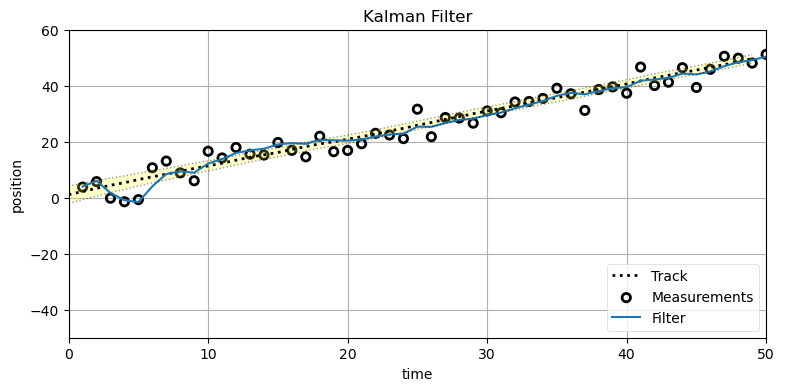

In [39]:
from numpy import dot
from scipy.linalg import inv

count = 50
track, zs = compute_dog_data(R_var, Q_var, count)
xs, cov = [], []
for z in zs:
    # predict
    x = dot(F, x)
    P = dot(F, P).dot(F.T) + Q
    
    #update
    S = dot(H, P).dot(H.T) + R
    K = dot(P, H.T).dot(inv(S))
    y = z - dot(H, x)
    x += dot(K, y)
    P = P - dot(K, H).dot(P)
    
    xs.append(x)
    cov.append(P)

xs, cov = np.array(xs), np.array(cov)
plot_track(xs[:, 0], track, zs, cov, plot_P=False, dt=dt)

The results are identical to the FilterPy version. Which you prefer is up to you. I prefer not polluting my namespace with variables such as `x`, `P`, and so on; `dog_filter.x` is, to me, more readable.

结果与 FilterPy 版本完全相同。你更喜欢哪一种取决于你自己。我不喜欢让 `x`、`P` 等变量充斥命名空间，对我而言，`dog_filter.x` 更易读。

More importantly, this example requires you to remember and program the equations for the Kalman filter. Sooner or later you will make a mistake. FilterPy's version ensures that your code will be correct. On the other hand, if you make a mistake in your definitions, such as making $\mathbf H$ a column vector instead of a row vector, FilterPy's error message will be harder to debug than this explicit code. 

更重要的是，这个示例要求你记住并编写卡尔曼滤波器方程。你迟早会犯错。FilterPy 的版本能确保你的代码正确。另一方面，如果你的定义有误，例如将 $\mathbf H$ 定义为列向量而非行向量，那么相比这段显式代码，FilterPy 的错误信息会更难调试。

FilterPy's KalmanFilter class provides additional functionality such as smoothing, batch processing, faded memory filtering, computation of the maximum likelihood function, and more. You get all of this functionality without having to explicitly program it.

FilterPy 的 KalmanFilter 类提供了额外功能，例如平滑、批处理、衰减记忆滤波、最大似然函数计算等。你无需显式编程就能获得这些功能。


### Summary
### 总结

We have learned the Kalman filter equations. Here they are all together for your review. There was a lot to learn, but I hope that as you went through each you recognized it's kinship with the equations in the univariate filter. In the *Kalman Math* chapter I will show you that if we set the dimension of $\mathbf x$ to one that these equations revert back to the equations for the univariate filter. This is not "like" the univariate filter - it is a multidimensional implementation of it.

我们已经学习了卡尔曼滤波器方程。这里将它们汇集在一起，供你复习。要学习的内容很多，但我希望你在逐一学习时，已经发现它们与单变量滤波器方程之间的联系。在 *Kalman Math* 一章中，我将说明，如果把 $\mathbf x$ 的维度设为一，这些方程就会还原为单变量滤波器的方程。这并非只是“类似于”单变量滤波器，而是它的多维实现。

$$
\begin{aligned}
\text{Predict Step}\\
\mathbf{\bar x} &= \mathbf{F x} + \mathbf{B u} \\
\mathbf{\bar P} &= \mathbf{FP{F}}^\mathsf T + \mathbf Q \\
\\
\text{Update Step}\\
\textbf{S} &= \mathbf{H\bar PH}^\mathsf T + \mathbf R \\
\mathbf K &= \mathbf{\bar PH}^\mathsf T \mathbf{S}^{-1} \\
\textbf{y} &= \mathbf z - \mathbf{H \bar x} \\
\mathbf x &=\mathbf{\bar x} +\mathbf{K\textbf{y}} \\
\mathbf P &= (\mathbf{I}-\mathbf{KH})\mathbf{\bar P}
\end{aligned}
$$

I want to share a form of the equations that you will see in the literature. There are many different notation systems used, but this gives you an idea of what to expect.

我想介绍一种你会在文献中看到的方程形式。现有许多不同的记号体系，但这能让你大致了解会遇到什么。

 $$
\begin{aligned}
\hat{\mathbf x}_{k\mid k-1} &= \mathbf F_k\hat{\mathbf x}_{k-1\mid k-1} + \mathbf B_k \mathbf u_k  \\
\mathbf P_{k\mid k-1} &=  \mathbf F_k \mathbf P_{k-1\mid k-1} \mathbf F_k^\mathsf T + \mathbf Q_k \	        
\tilde{\mathbf y}_k &= \mathbf z_k - \mathbf H_k\hat{\mathbf x}_{k\mid k-1}\\
\mathbf{S}_k &= \mathbf H_k \mathbf P_{k\mid k-1} \mathbf H_k^\mathsf T + \mathbf R_k \\
\mathbf K_k &= \mathbf P_{k\mid k-1}\mathbf H_k^\mathsf T \mathbf{S}_k^{-1}\\
\hat{\mathbf x}_{k\mid k} &= \hat{\mathbf x}_{k\mid k-1} + \mathbf K_k\tilde{\mathbf y}_k\\
\mathbf P_{k|k} &= (I - \mathbf K_k \mathbf H_k) \mathbf P_{k|k-1}
\\\end{aligned}
$$

This notation uses the Bayesian $a\mid b$ notation, which means $a$ given the evidence of $b$. The hat means estimate. Thus $\hat{\mathbf x}_{k\mid k}$ means the estimate of the state $\mathbf x$ at step $k$ (the first $k$) given the evidence from step $k$ (the second $k$). The posterior, in other words. $\hat{\mathbf x}_{k\mid k-1}$ means the estimate for the state $\mathbf x$ at step $k$ given the estimate from step $k - 1$. The prior, in other words. 

这种记号使用贝叶斯的 $a\mid b$ 表示法，意思是在证据 $b$ 条件下的 $a$。帽号表示估计。因此，$\hat{\mathbf x}_{k\mid k}$ 表示在第 $k$ 步，根据第 $k$ 步的证据对状态 $\mathbf x$ 的估计，前一个 $k$ 表示估计所在的步骤，后一个 $k$ 表示所依据证据的步骤。换言之，它是后验。$\hat{\mathbf x}_{k\mid k-1}$ 表示在第 $k$ 步，根据第 $k - 1$ 步的估计得到的状态 $\mathbf x$ 的估计。换言之，它是先验。

This notation, copied from [Wikipedia](https://en.wikipedia.org/wiki/Kalman_filter#Details) [[1]](#[wiki_article]), allows a mathematician to express himself exactly. In formal publications presenting new results this precision is necessary. As a programmer I find it fairly unreadable. I am used to thinking about variables changing state as a program runs, and do not use a different variable name for each new computation. There is no agreed upon format in the literature, so each author makes different choices. I find it challenging to switch quickly between books and papers, and so have adopted my admittedly less precise notation. Mathematicians may write scathing emails to me, but I hope programmers and students will rejoice at my simplified notation.

这种记号来自 [Wikipedia](https://en.wikipedia.org/wiki/Kalman_filter#Details) [[1]](#[wiki_article])，它使数学家能够准确地表达。在正式发表新结果的文章中，这种精确性是必要的。作为程序员，我觉得它相当难读。我习惯于把变量看作随程序运行而改变状态的量，不会为每一次新计算使用不同的变量名。文献中没有公认的格式，所以每位作者都会作出不同选择。我发现要在书籍和论文之间迅速切换很有挑战，因此采用了我自己承认不够精确的记号。数学家或许会给我写措辞严厉的邮件，但我希望程序员和学生会因我的简化记号而高兴。

The **Symbology** Appendix lists the notation used by various authors. This brings up another difficulty. Different authors use different variable names. $\mathbf x$ is fairly universal, but after that it is anybody's guess. For example, it is common to use $\mathbf{A}$ for what I call $\mathbf F$. You must read carefully, and hope that the author defines their variables (they often do not).

**Symbology** 附录列出了不同作者所使用的记号。这又带来一个困难。不同作者使用不同的变量名。$\mathbf x$ 相当通用，但除此之外就难以预料了。例如，通常会用 $\mathbf{A}$ 表示我称作 $\mathbf F$ 的量。你必须仔细阅读，并希望作者定义了他们的变量，他们往往并没有这样做。

If you are a programmer trying to understand a paper's equations, I suggest starting by removing all of the superscripts, subscripts, and diacriticals, replacing them with a single letter. If you work with equations like this every day this is superfluous advice, but when I read I am usually trying to understand the flow of computation. To me it is far more understandable to remember that $P$ in this step represents the updated value of $P$ computed in the last step, as opposed to trying to remember what $P_{k-1}(+)$ denotes, and what its relation to $P_k(-)$ is, if any, and how any of that relates to the completely different notation used in the paper I read 5 minutes ago.

如果你是一名试图理解论文方程的程序员，我建议先移除所有上标、下标和变音符号，用单个字母替换它们。如果你每天都处理这样的方程，这个建议或许多余，但我阅读时通常是在试图理解计算流程。对我来说，记住此步骤中的 $P$ 表示上一步计算出的 $P$ 的更新值，要比试图记住 $P_{k-1}(+)$ 表示什么、它与 $P_k(-)$ 有何关系，以及这些又与我五分钟前读过的论文中完全不同的记号有何联系，要容易理解得多。


## Exercise: Show Effect of Hidden Variables
## 练习：展示隐藏变量的效果

In our filter velocity is a hidden variable. How would a filter perform if we did not use velocity in the state?

在我们的滤波器中，速度是一个隐藏变量。如果不在状态中使用速度，滤波器的表现会如何？

Write a Kalman filter that uses the state $\mathbf x=\begin{bmatrix}x\end{bmatrix}$ and compare it against a filter that uses $\mathbf x=\begin{bmatrix}x & \dot x\end{bmatrix}^\mathsf T$.

编写一个使用状态 $\mathbf x=\begin{bmatrix}x\end{bmatrix}$ 的卡尔曼滤波器，并将其与使用 $\mathbf x=\begin{bmatrix}x & \dot x\end{bmatrix}^\mathsf T$ 的滤波器进行比较。


In [40]:
# your code here

### Solution
### 解答

We've already implemented a Kalman filter for position and velocity, so I will provide the code without much comment, and then plot the result.

我们已经实现了一个用于位置和速度的卡尔曼滤波器，因此我将不作过多说明，直接给出代码，然后绘制结果。


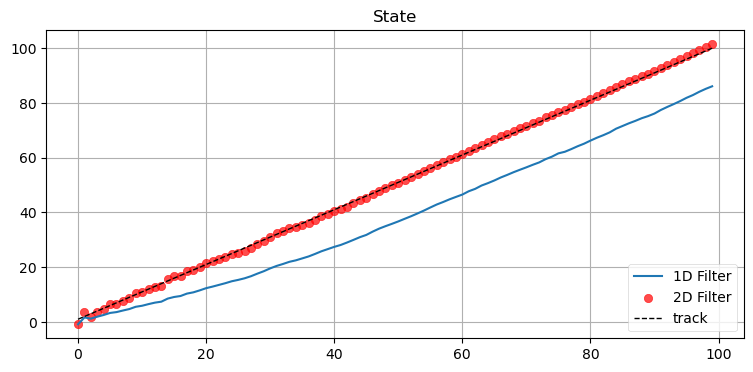

In [41]:
from math import sqrt
from numpy.random import randn

def univariate_filter(x0, P, R, Q):
    f = KalmanFilter(dim_x=1, dim_z=1, dim_u=1)
    f.x = np.array([[x0]])
    f.P *= P
    f.H = np.array([[1.]])
    f.F = np.array([[1.]])
    f.B = np.array([[1.]])
    f.Q *= Q
    f.R *= R
    return f

def plot_1d_2d(xs, xs1d, xs2d):
    plt.plot(xs1d, label='1D Filter')
    plt.scatter(range(len(xs2d)), xs2d, c='r', alpha=0.7, label='2D Filter')
    plt.plot(xs, ls='--', color='k', lw=1, label='track')
    plt.title('State')
    plt.legend(loc=4)
    plt.show()
    
def compare_1D_2D(x0, P, R, Q, vel, u=0):
    # storage for filter output
    xs, xs1, xs2 = [], [], []

    # 1d KalmanFilter
    f1D = univariate_filter(x0, P, R, Q)

    #2D Kalman filter
    f2D = pos_vel_filter(x=(x0, vel), P=P, R=R, Q=0)
    
    pos = 0 # true position
    for i in range(100):
        pos += vel
        xs.append(pos)

        # control input u - discussed below
        f1D.predict(u=u)
        f2D.predict()
        
        z = pos + randn()*sqrt(R) # measurement
        f1D.update(z)
        f2D.update(z)
        
        xs1.append(f1D.x[0])
        xs2.append(f2D.x[0])
    plt.figure()
    plot_1d_2d(xs, xs1, xs2)

compare_1D_2D(x0=0, P=50., R=5., Q=.02, vel=1.) 

### Discussion
### 讨论

The filter that incorporates velocity into the state produces much better estimates than the filter that only tracks position. The univariate filter has no way to estimate the velocity or change in position, so it lags the tracked object. 

将速度纳入状态的滤波器产生的估计结果，远优于只跟踪位置的滤波器。单变量滤波器无法估计速度或位置变化，因此会落后于被跟踪对象。

In the univarate Kalman filter chapter we had a control input `u` to the predict equation:

在单变量卡尔曼滤波器章节中，我们为预测方程提供了一个控制输入 `u`：

```python
    def predict(self, u=0.0):
        self.x += u
        self.P += self.Q
```

Let's try specifying the control input:

让我们尝试指定控制输入：


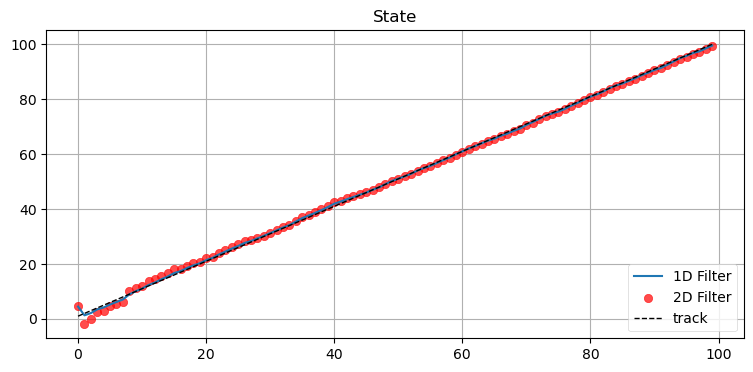

In [42]:
compare_1D_2D(x0=0, P=50., R=5., Q=.02, vel=1., u=1.) 

Here the performance of the two filters are similar, and perhaps the univariate filter is tracking more closely. But let's see what happens when the actual velocity `vel` is different from the control input `u`:

这里两个滤波器的表现相近，单变量滤波器或许跟踪得更紧密一些。但让我们看看当实际速度 `vel` 与控制输入 `u` 不同时会发生什么：


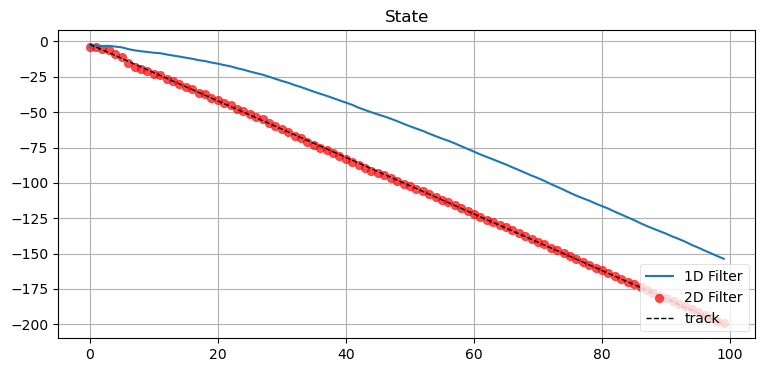

In [43]:
compare_1D_2D(x0=0, P=50., R=5., Q=.02, vel=-2., u=1.) 

If we are tracking a robot which we are also controlling the univariate filter can do a very good job because the control input allows the filter to make an accurate prediction. But if we are tracking passively the control input is not much help unless we can make an accurate *apriori* guess as to the velocity. This is rarely possible.

如果我们正在跟踪一个同时也由我们控制的机器人，单变量滤波器可以表现得非常好，因为控制输入使滤波器能够作出准确预测。但如果是被动跟踪，控制输入的帮助不大，除非我们能对速度作出准确的 *先验* 猜测。这很少能够做到。


## How Velocity is Calculated
## 如何计算速度

I haven't explained how the filter computes the velocity, or any hidden variable. If we plug in the values we calculated for each of the filter's matrices we can see what happens.

我尚未解释滤波器如何计算速度或任何隐藏变量。将我们为滤波器各个矩阵算出的值代入后，就能看到发生了什么。

First we need to compute the system uncertainty.

首先，我们需要计算系统不确定性。

$$\begin{aligned}
\textbf{S} &= \mathbf{H\bar PH}^\mathsf T + \mathbf R \\
&= \begin{bmatrix} 1 & 0\end{bmatrix}
\begin{bmatrix}\sigma^2_x & \sigma_{xv} \\ \sigma_{xv} & \sigma^2_v\end{bmatrix}
\begin{bmatrix} 1 \\ 0\end{bmatrix} + \begin{bmatrix}\sigma_z^2\end{bmatrix}\\
&= \begin{bmatrix}\sigma_x^2 & \sigma_{xv}\end{bmatrix}\begin{bmatrix} 1 \\ 0\end{bmatrix}+ \begin{bmatrix}\sigma_z^2\end{bmatrix} \\
&= \begin{bmatrix}\sigma_x^2 +\sigma_z^2\end{bmatrix}
\end{aligned}$$

Now that we have $\mathbf S$ we can find the value for the Kalman gain:

现在有了 $\mathbf S$，我们就可以求出卡尔曼增益的值：

$$\begin{aligned}
\mathbf K &= \mathbf{\bar PH}^\mathsf T \mathbf{S}^{-1} \\
&= \begin{bmatrix}\sigma^2_x & \sigma_{xv} \\ \sigma_{xv} & \sigma^2_v\end{bmatrix}
\begin{bmatrix} 1 \\ 0\end{bmatrix}
\begin{bmatrix}\frac{1}{\sigma_x^2 +\sigma_z^2}\end{bmatrix} \\
&= \begin{bmatrix}\sigma^2_x  \\ \sigma_{xv}\end{bmatrix}
\begin{bmatrix}\frac{1}{\sigma_x^2 +\sigma_z^2}\end{bmatrix} \\
&= \begin{bmatrix}\sigma^2_x/(\sigma_x^2 +\sigma_z^2)  \\ \sigma_{xv}/(\sigma_x^2 +\sigma_z^2)\end{bmatrix}
\end{aligned}
$$

In other words, the Kalman gain for $x$ is 

换言之，$x$ 的卡尔曼增益为

$$K_x = \frac{VAR(x)}{VAR(x)+VAR(z)}$$

This should be very familiar to you from the univariate case. 

这应该会让你想起单变量情形。

The Kalman gain for the velocity $\dot x$ is

速度 $\dot x$ 的卡尔曼增益为

$$K_{\dot x} = \frac{COV(x, \dot x)}{VAR(x)+VAR(z)}$$

What is the effect of this? Recall that we compute the state as 

这会产生什么效果？回忆一下，我们按如下方式计算状态：

$$\begin{aligned}\mathbf x 
&=\mathbf{\bar x}+\mathbf K(z-\mathbf{Hx)} \\
&= \mathbf{\bar x}+\mathbf Ky\end{aligned}$$

Here the residual $y$ is a scalar. Therefore it is multiplied into each element of $\mathbf K$. Therefore we have

这里的残差 $y$ 是一个标量。因此，它会乘入 $\mathbf K$ 的每个元素。因此有

$$\begin{bmatrix}x \\ \dot x\end{bmatrix}=\begin{bmatrix}\bar x \\ \bar{\dot x}\end{bmatrix} + \begin{bmatrix}K_x \\ K_{\dot x}\end{bmatrix}y$$

Which gives this system of equations: 

由此得到以下方程组：

$$\begin{aligned}x& = \bar x + yK_x\\
\dot x &= \bar{\dot x} + yK_{\dot x}\end{aligned}$$

The prediction $\bar x$ was computed as $x + \bar x \Delta t$. If the prediction was perfect then the residual will be $y=0$ (ignoring noise in the measurement) and the velocity estimate will be unchanged. On the other hand, if the velocity estimate was very bad then the prediction will be very bad, and the residual will be large: $y >> 0$. In this case we update the velocity estimate with $yK_{\dot x}$. $K_{\dot x}$ is proportional to $COV(x,\dot x)$. Therefore the velocity is updated by the error in the position times the value proportional to the covariance between the position and velocity. The higher the correlation the larger the correction. 

预测值 $\bar x$ 是按 $x + \bar x \Delta t$ 计算的。如果预测完美，那么残差将为 $y=0$，忽略测量中的噪声后，速度估计不会改变。反之，如果速度估计很差，预测也会很差，残差就会很大：$y >> 0$。此时我们用 $yK_{\dot x}$ 更新速度估计。$K_{\dot x}$ 与 $COV(x,\dot x)$ 成正比。因此，速度会根据位置误差乘以一个与位置和速度之间协方差成正比的值来更新。相关性越高，修正越大。

To bring this full circle, $COV(x,\dot x)$ are the off-diagonal elements of $\mathbf P$. Recall that those values were computed with $\mathbf{FPF}^\mathsf T$. So the covariance of position and velocity is computed during the predict step. The Kalman gain for the velocity is proportional to this covariance, and we adjust the velocity estimate based on how inaccurate it was during the last epoch times a value proportional to this covariance. 

回到前面的推导，$COV(x,\dot x)$ 就是 $\mathbf P$ 的非对角元素。回忆一下，这些值是通过 $\mathbf{FPF}^\mathsf T$ 计算的。因此，位置和速度的协方差是在预测步骤中计算的。速度的卡尔曼增益与该协方差成正比，我们依据上一时刻速度估计的不准确程度，再乘以一个与此协方差成正比的值，来调整速度估计。

In summary, these linear algebra equations may be unfamiliar to you, but computation is actually very simple. It is essentially the same computation that we performed in the g-h filter. Our constants are different in this chapter because we take the noise in the process model and sensors into account, but the math is the same.

总之，这些线性代数方程对你而言或许并不熟悉，但计算实际上非常简单。它本质上与我们在 g-h 滤波器中执行的计算相同。本章中的常数有所不同，因为我们考虑了过程模型和传感器中的噪声，但数学原理是一样的。


## Adjusting the Filter
## 调整滤波器

Let's start varying our parameters to see the effect of various changes. This is a very normal thing to be doing with Kalman filters. It is difficult, and often impossible to exactly model our sensors. An imperfect model means imperfect output from our filter. Engineers spend a lot of time tuning Kalman filters so that they perform well with real world sensors. We will spend time now to learn the effect of these changes. As you learn the effect of each change you will develop an intuition for how to design a Kalman filter. Designing a Kalman filter is as much art as science. We are modeling a physical system using math, and models are imperfect.

让我们开始改变参数，看看各种变化会产生什么影响。对卡尔曼滤波器来说，这是一项很常见的工作。要精确地建模传感器很困难，而且往往不可能。模型不完美，滤波器的输出也会不完美。工程师会花大量时间调整卡尔曼滤波器，使其能够与现实世界的传感器良好配合。现在我们将花些时间了解这些变化的影响。随着你逐渐了解每项变化的作用，你会形成如何设计卡尔曼滤波器的直觉。设计卡尔曼滤波器既是一门科学，也是一门艺术。我们在用数学建模物理系统，而模型并不完美。

Let's look at the effects of the measurement noise $\mathbf R$ and process noise $\mathbf Q$. We will want to see the effect of different settings for $\mathbf R$ and $\mathbf Q$, so I have given the measurements a variance of 225 meters squared. That is very large, but it magnifies the effects of various design choices on the graphs, making it easier to recognize what is happening. Our first experiment holds $\mathbf R$ constant while varying $\mathbf Q$.

让我们考察测量噪声 $\mathbf R$ 和过程噪声 $\mathbf Q$ 的影响。我们希望看到 $\mathbf R$ 与 $\mathbf Q$ 采用不同设置时的效果，因此我将测量值的方差设为 225 平方米。这个数值很大，但它会放大图中各种设计选择的效果，让我们更容易辨认发生了什么。第一个实验保持 $\mathbf R$ 不变，同时改变 $\mathbf Q$。


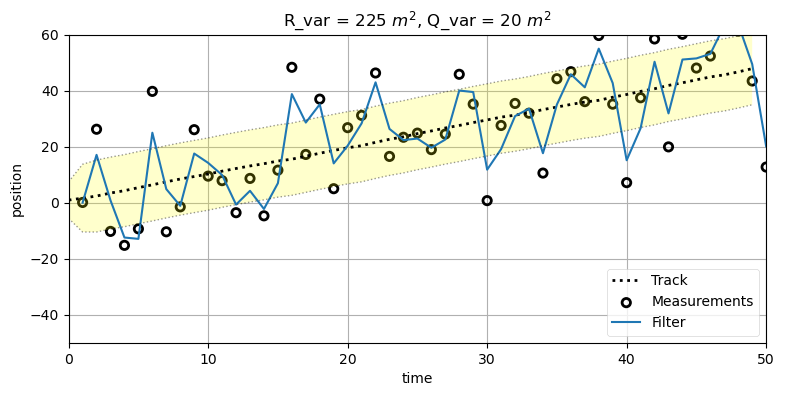

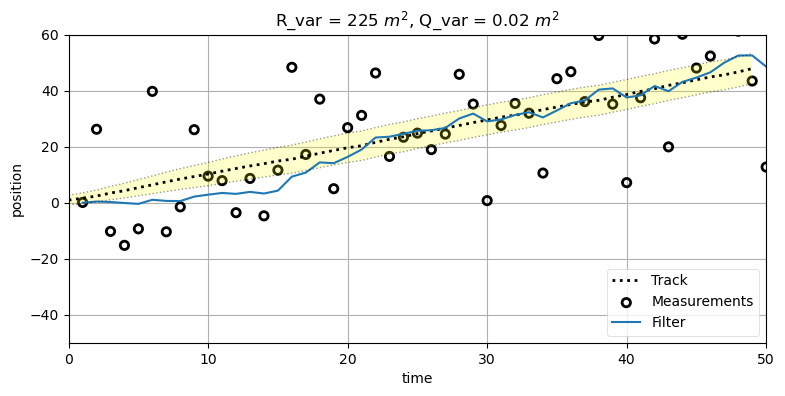

In [44]:
from numpy.random import seed
seed(2)
trk, zs = compute_dog_data(z_var=225, process_var=.02, count=50)

run(track=trk, zs=zs, R=225, Q=200, P=P, plot_P=False, 
    title='R_var = 225 $m^2$, Q_var = 20 $m^2$')
run(track=trk, zs=zs, R=225, Q=.02, P=P, plot_P=False, 
    title='R_var = 225 $m^2$, Q_var = 0.02 $m^2$');

The filter in the first plot should follow the noisy measurement closely. In the second plot the filter should vary from the measurement quite a bit, and be much closer to a straight line than in the first graph. Why does ${\mathbf Q}$ affect the plots this way?

第一幅图中的滤波器应当紧密跟随带噪声的测量值。在第二幅图中，滤波器应当与测量值有相当大的偏离，并且比第一幅图更接近一条直线。为什么 ${\mathbf Q}$ 会以这种方式影响图形？

Let's remind ourselves of what the term *process uncertainty* means. Consider the problem of tracking a ball. We can accurately model its behavior in a vacuum with math, but with wind, varying air density, temperature, and a spinning ball with an imperfect surface our model will diverge from reality. 

让我们回顾一下术语 *过程不确定性* 的含义。考虑跟踪一个球的问题。在真空中，我们可以用数学精确地建模它的行为；但在存在风、空气密度和温度变化，以及球在旋转且表面不完美的情况下，我们的模型就会偏离现实。

In the first case we set `Q_var=20 m^2`, which is quite large. In physical terms this is telling the filter "I don't trust my motion prediction step" as we are saying that the variance in the velocity is 20. Strictly speaking, we are telling the filter there is a lot of external noise that we are not modeling with $\small{\mathbf F}$, but the upshot of that is to not trust the motion prediction step. The filter will be computing velocity ($\dot x$), but then mostly ignoring it because we are telling the filter that the computation is extremely suspect. Therefore the filter has nothing to trust but the measurements, and thus it follows the measurements closely. 

在第一种情形中，我们设定 `Q_var=20 m^2`，这是相当大的值。从物理角度看，这是在告诉滤波器“我不信任自己的运动预测步骤”，因为我们说速度的方差为 20。严格来说，我们是在告诉滤波器，存在大量未通过 $\small{\mathbf F}$ 建模的外部噪声，但其结果就是不应信任运动预测步骤。滤波器会计算速度 $\dot x$，但会基本忽略它，因为我们告诉滤波器这一计算极不可靠。因此，滤波器除了测量值之外没有其他可信依据，于是会紧密跟随测量值。

In the second case we set `Q_var=0.02 m^2`, which is quite small. In physical terms we are telling the filter "trust the prediction, it is really good!". More strictly this actually says there is very small amounts of process noise (variance 0.02 $m^2$), so the process model is very accurate. So the filter ends up ignoring some of the measurement as it jumps up and down, because the variation in the measurement does not match our trustworthy velocity prediction.

在第二种情形中，我们设定 `Q_var=0.02 m^2`，这是相当小的值。从物理角度看，我们是在告诉滤波器“相信预测，它真的很好！”更严格地说，这实际表示过程噪声非常小，方差为 0.02 $m^2$，因此过程模型非常准确。于是，当测量值上下跳动时，滤波器会忽略其中一部分，因为测量值的变化与我们可信的速度预测不一致。

Now let's set `Q_var` to $0.2\, m^2$, and bump `R_var` up to $10,000\, m^2$. This is telling the filter that the measurement noise is very large. 

现在让我们将 `Q_var` 设为 $0.2\, m^2$，并将 `R_var` 提高至 $10,000\, m^2$。这是在告诉滤波器测量噪声非常大。


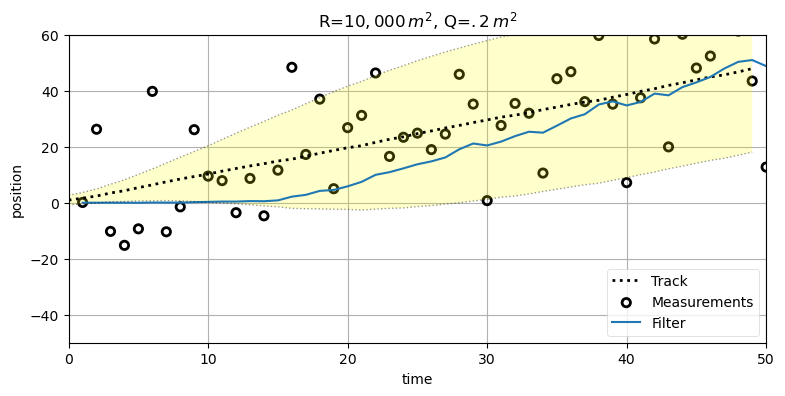

In [45]:
run(track=trk, zs=zs, R=10000, Q=.2, P=P, plot_P=False, 
    title='R=$10,000\, m^2$, Q=$.2\, m^2$');

The effect of this can be subtle. We have created an suboptimal filter because the actual measurement noise variance is 225 $m^2$, not 10,000 $m^2$. By setting the filter's noise variance so high we force the filter to favor the prediction over the measurement. This can lead to apparently very smooth and good looking results. In the chart above the track may look extremely good to you since it follows the ideal path very closely. But, the 'great' behavior at the start should give you pause - the filter has not converged yet ($\mathbf P$ is still large) so it should not be able to be so close to the actual position. We can see that $\mathbf P$ has not converged because the entire chart is colored with the yellow background denoting the size of $\mathbf P$. Let's see the result of a bad initial guess for the position by guessing the initial position to be 50 m and the initial velocity to be 1 m/s.

这种影响可能很微妙。我们创建了一个次优滤波器，因为实际的测量噪声方差是 225 $m^2$，而不是 10,000 $m^2$。将滤波器的噪声方差设得如此之高，会迫使滤波器更偏向预测而非测量。这可能产生看似非常平滑、漂亮的结果。在上图中，这条轨迹可能看起来极好，因为它非常贴近理想路径。但是，开始时“出色”的表现应当让你警惕，滤波器尚未收敛，$\mathbf P$ 仍然很大，因此它本不应如此接近实际位置。我们可以看出 $\mathbf P$ 尚未收敛，因为整张图都以表示 $\mathbf P$ 大小的黄色背景着色。让我们将初始位置猜为 50 m、初始速度猜为 1 m/s，看看位置初始猜测不佳时的结果。


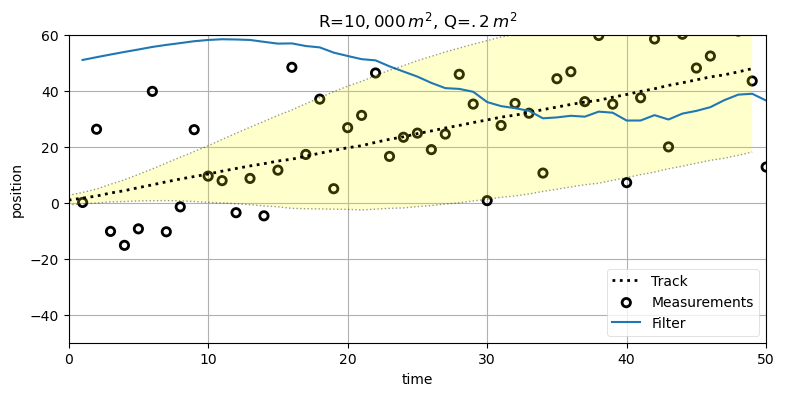

In [46]:
run(track=trk, zs=zs, R=10000, Q=.2, P=P, plot_P=False,
    x0=np.array([50., 1.]), 
    title='R=$10,000\, m^2$, Q=$.2\, m^2$');

Here we can see that the filter cannot acquire the track. This happens because even though the filter is getting reasonably good measurements it assumes that the measurements are bad, and eventually predicts forward from a bad position at each step. If you think that perhaps that bad initial position would give similar results for a smaller measurement noise, let's set it back to the correct value of 225 $m^2$.

这里我们可以看到，滤波器无法捕获轨迹。这是因为尽管滤波器获得的测量值还算不错，它却假定测量值很差，最终在每一步都从错误的位置向前预测。如果你认为较小的测量噪声下，这个糟糕的初始位置或许会得到相似结果，那就让我们将它设回正确的 225 $m^2$。


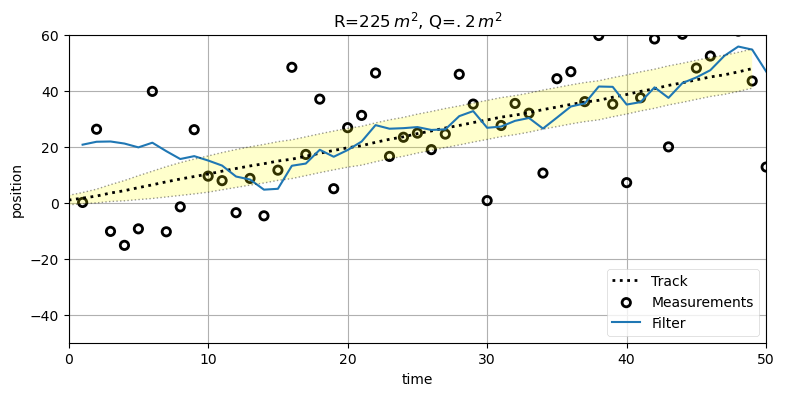

In [47]:
run(track=trk, zs=zs, R=225, Q=.2, P=P, plot_P=False, 
    x0=np.array([20., 1.]),
    title='R=$225\, m^2$, Q=$.2\, m^2$');

Here we see that the filter initially struggles for several iterations to acquire the track, but then it accurately tracks our dog. In fact, this is nearly optimum - we have not designed $\mathbf Q$ optimally, but $\mathbf R$ is optimal. A rule of thumb for $\mathbf Q$ is to set it between $\frac{1}{2}\Delta a$ to $\Delta a$, where $\Delta a$ is the maximum amount that the acceleration will change between sample periods. This only applies for the assumption we are making in this chapter - that acceleration is constant and uncorrelated between each time period. In the Kalman Math chapter we will discuss several different ways of designing $\mathbf Q$.

这里我们看到，滤波器在最初几次迭代中难以捕获轨迹，但随后便能准确跟踪我们的狗。实际上，这已接近最优，尽管我们没有将 $\mathbf Q$ 设计为最优值，但 $\mathbf R$ 是最优的。对于 $\mathbf Q$，一个经验法则是将其设在 $\frac{1}{2}\Delta a$ 到 $\Delta a$ 之间，其中 $\Delta a$ 是相邻采样周期之间加速度可能变化的最大幅度。这只适用于本章所作的假设，即加速度在每个时间段内恒定，且各时间段之间不相关。在卡尔曼数学章节中，我们将讨论几种设计 $\mathbf Q$ 的不同方法。

To some extent you can get similar looking output by varying either ${\mathbf R}$ or ${\mathbf Q}$, but I urge you to not 'magically' alter these until you get output that you like. Always think about the physical implications of these assignments, and vary ${\mathbf R}$ and/or ${\mathbf Q}$ based on your knowledge of the system you are filtering. Back that up with extensive simulations and/or trial runs of real data.

在某种程度上，改变 ${\mathbf R}$ 或 ${\mathbf Q}$ 都可能得到外观相似的输出，但我建议你不要为了得到喜欢的输出而“神奇地”调整它们。始终要考虑这些设定在物理上的含义，并基于你对所滤波系统的了解来改变 ${\mathbf R}$ 和/或 ${\mathbf Q}$。还应通过大量仿真和/或真实数据的试运行来验证。


## A Detailed Examination of the Covariance Matrix
## 协方差矩阵的详细考察

Let's start by revisiting plotting a track. I've hard coded the data and noise in `zs_var_275` to avoid being at the mercy of the random number generator, which might generate data that does not illustrate what I want to talk about. I will start with `P=500`.

让我们重新讨论如何绘制轨迹。我将 `zs_var_275` 中的数据和噪声硬编码，以免受随机数生成器的影响，因为它可能生成无法说明我想讨论内容的数据。我将从 `P=500` 开始。


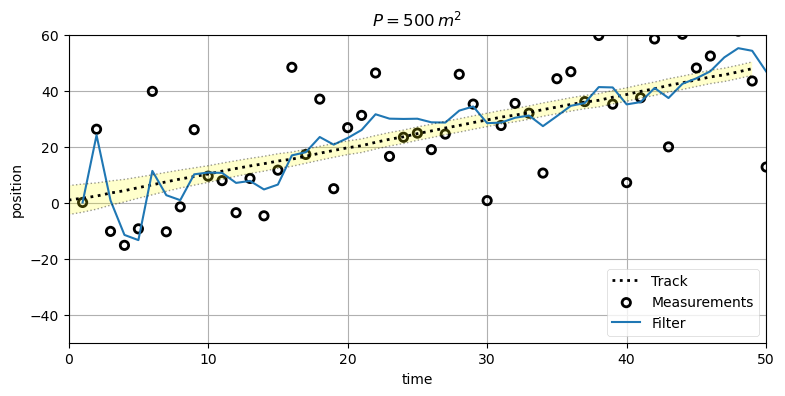

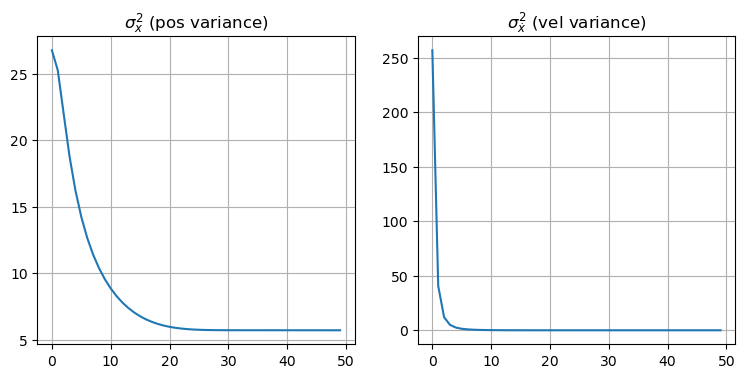

In [48]:
import kf_book.mkf_internal as mkf_internal

var = 27.5
data = mkf_internal.zs_var_275()
run(track=trk, zs=zs, R=var, Q=.02, P=500., plot_P=True, 
    title='$P=500\, m^2$');

Looking at the output we see a very large spike in the filter output at the beginning. We set $\text{P}=500\, \mathbf{I}_2$ (this is shorthand notation for a 2x2 diagonal matrix with 500 in the diagonal). We now have enough information to understand what this means, and how the Kalman filter treats it. The 500 in the upper left hand corner corresponds to $\sigma^2_x$; therefore we are saying the standard deviation of `x` is $\sqrt{500}$, or roughly 22.36 m. Roughly 99% of the samples occur withing $3\sigma$, therefore $\sigma^2_x=500$ is telling the Kalman filter that the prediction (the prior) could be up to 67 meters off. That is a large error, so when the measurement spikes the Kalman filter distrusts its own estimate and jumps wildly to try to incorporate the measurement. Then, as the filter evolves $\mathbf P$ quickly converges to a more realistic value.

从输出可以看到，滤波器输出在开始时出现了非常大的尖峰。我们设定 $\text{P}=500\, \mathbf{I}_2$，这是一种简写，表示一个对角线上元素均为 500 的 2x2 对角矩阵。现在我们已有足够的信息来理解这意味着什么，以及卡尔曼滤波器如何处理它。左上角的 500 对应于 $\sigma^2_x$，因此我们是在说 `x` 的标准差为 $\sqrt{500}$，约为 22.36 m。大约 99% 的样本位于 $3\sigma$ 范围内，因此 $\sigma^2_x=500$ 告诉卡尔曼滤波器，预测，即先验，最多可能偏离 67 米。这是很大的误差，所以当测量值出现尖峰时，卡尔曼滤波器不信任自己的估计，并剧烈跳变以尝试纳入该测量值。随后，随着滤波器不断演化，$\mathbf P$ 会迅速收敛到更符合实际的值。

Let's look at the math behind this. The equation for the Kalman gain is

让我们看看其背后的数学原理。卡尔曼增益的方程为

$$\mathbf K = \mathbf{\bar P} \mathbf H^\mathsf T\mathbf{S}^{-1} \approx \frac{\mathbf{\bar P}\mathbf H^\mathsf T}{\mathbf{S}} 
\approx \frac{\mathsf{uncertainty}_\mathsf{prediction}}{\mathsf{uncertainty}_\mathsf{measurement}}\mathbf H^\mathsf T
$$

It is a ratio of the uncertainty of the prediction vs measurement. Here the uncertainty in the prediction is large, so $\mathbf K$ is large (near 1 if this was a scalar). $\mathbf K$ is multiplied by the residual $\textbf{y} = \mathbf z - \mathbf{H \bar x}$, which is the measurement minus the prediction, so a large $\mathbf K$ favors the measurement. Therefore if $\mathbf P$ is large relative to the sensor uncertainty $\mathbf R$ the filter will form most of the estimate from the measurement. 

它是预测不确定性与测量不确定性的比值。这里预测的不确定性很大，因此 $\mathbf K$ 很大，若为标量则接近 1。$\mathbf K$ 要乘以残差 $\textbf{y} = \mathbf z - \mathbf{H \bar x}$，即测量值减去预测值，所以较大的 $\mathbf K$ 会偏向测量值。因此，若相对于传感器不确定性 $\mathbf R$ 而言 $\mathbf P$ 很大，滤波器便会主要依据测量值形成估计。

Now let us see the effect of a smaller initial value of $\mathbf P = 1.0\, \mathbf{I}_2$.

现在让我们看看较小的初始值 $\mathbf P = 1.0\, \mathbf{I}_2$ 所产生的影响。


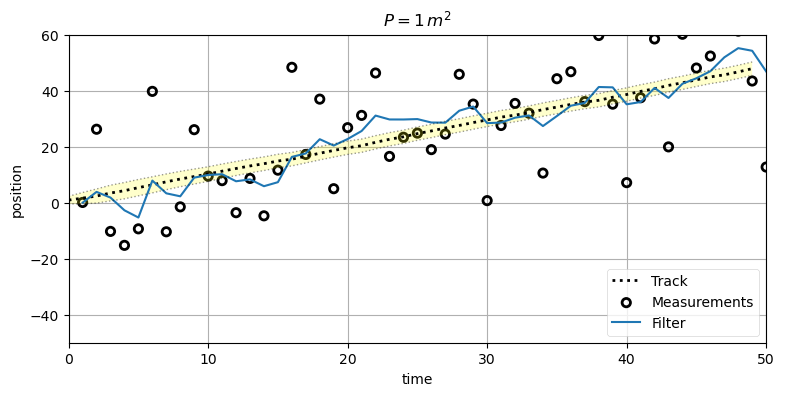

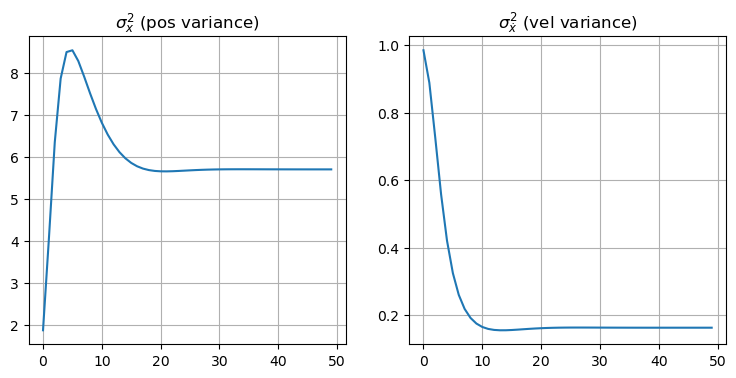

In [49]:
run(track=trk, zs=zs, R=var, Q=.02, P=1., plot_P=True, 
    title='$P=1\, m^2$');

This *looks* good at first blush. The plot does not have the spike that the former plot did; the filter starts tracking the measurements and doesn't take any time to settle to the signal. However, if we look at the plots for P you can see that there is an initial spike for the variance in position, and that it never really converges. Poor design leads to a long convergence time, and suboptimal results. 

乍看之下，这*似乎*不错。图中没有前一幅图所出现的尖峰，滤波器开始跟踪测量值，也无需时间便能稳定地跟随信号。然而，如果查看 $\mathbf P$ 的图，就会发现位置方差在初始时出现尖峰，并且始终没有真正收敛。设计不佳会导致较长的收敛时间和次优的结果。

So despite the filter tracking very close to the actual signal we cannot conclude that the 'magic' is to use a small $\mathbf P$. Yes, this will avoid having the Kalman filter take time to accurately track the signal, but if we are truly uncertain about the initial measurements this can cause the filter to generate very bad results. If we are tracking a living object we are probably very uncertain about where it is before we start tracking it. On the other hand, if we are filtering the output of a thermometer, we are as certain about the first measurement as the 1000th. For your Kalman filter to perform well you must set $\mathbf P$ to a value that truly reflects your knowledge about the data. 

因此，尽管滤波器非常贴近真实信号进行跟踪，我们也不能断定其中的“秘诀”是使用较小的 $\mathbf P$。的确，这能避免卡尔曼滤波器花时间准确跟踪信号，但如果我们确实不确定初始测量值，这样做可能使滤波器产生非常糟糕的结果。若我们跟踪的是活体对象，那么在开始跟踪前，我们很可能非常不确定它的位置。另一方面，若我们滤波的是温度计输出，对于第一个测量值的确定程度与第 1000 个测量值相同。要使卡尔曼滤波器表现良好，必须将 $\mathbf P$ 设为能够真实反映你对数据所掌握知识的值。

Let's see the result of a bad initial estimate coupled with a very small $\mathbf P$. We will set our initial estimate at x = 100 m (whereas the dog actually starts at 0m), but set `P=1` m$^2$. This is clearly an incorrect value for $\mathbf P$ as the estimate is off by 100 m but we tell the filter that it the $3\sigma$ error is 3 m.

让我们看看糟糕的初始估计与非常小的 $\mathbf P$ 结合时的结果。我们将初始估计设为 x = 100 m，而狗实际上从 0m 处开始，但将 `P=1` m$^2$。这显然是 $\mathbf P$ 的错误取值，因为估计偏差为 100 m，但我们却告诉滤波器其 $3\sigma$ 误差为 3 m。


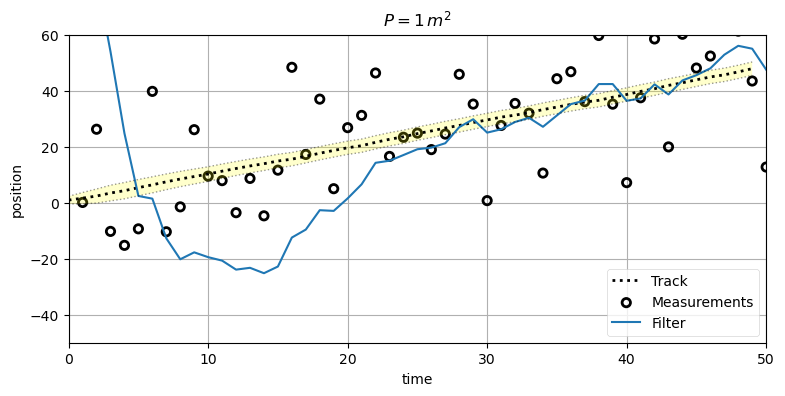

In [50]:
x = np.array([100., 0.])
run(track=trk, zs=zs, R=var, Q=.02, P=1., x0=x,
    plot_P=False, title='$P=1\, m^2$');

We can see that the initial estimates are terrible and that it takes the filter a long time to start converging onto the signal . This is because we told the Kalman filter that we strongly believe in our initial estimate of 100 m and were incorrect in that belief.

可以看到，初始估计非常糟糕，滤波器需要很长时间才开始向信号收敛。这是因为我们告诉卡尔曼滤波器，我们非常相信初始的 100 m 估计，但这种信念是错误的。

Now, let's provide a more reasonable value for `P` and see the difference.

现在，让我们为 `P` 提供一个更合理的值，看看差异。


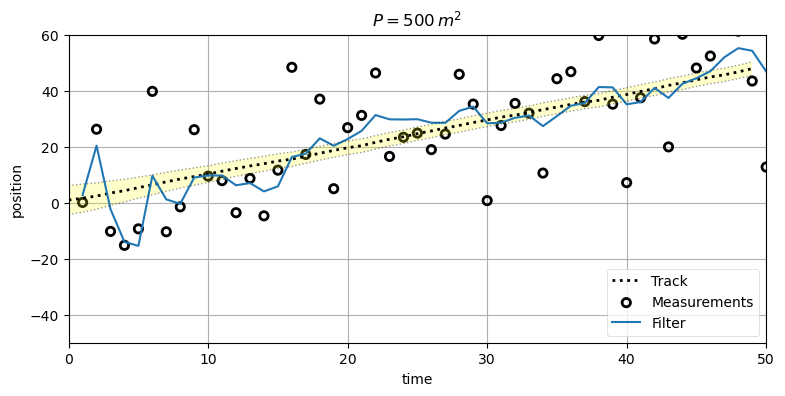

In [51]:
x = np.array([100., 0.])
run(track=trk, zs=zs, R=var, Q=.02, P=500., x0=x,
   plot_P=False, title='$P=500\, m^2$');

In this case the Kalman filter is very uncertain about the initial state, so it converges onto the signal much faster. It is producing good output after only 5 to 6 epochs. With the theory we have developed so far this is about as good as we can do. However, this scenario is a bit artificial; if we do not know where the object is when we start tracking we do not initialize the filter to some arbitrary value, such as 0 m or 100 m. I address this in the **Filter Initialization** section below.

在这种情况下，卡尔曼滤波器对初始状态非常不确定，因此它向信号收敛得快得多。仅经过 5 到 6 个周期后，它便能产生良好的输出。就目前为止我们建立的理论而言，这已接近我们所能达到的最佳效果。不过，这个场景有些人为。如果开始跟踪时不知道对象的位置，我们不会将滤波器初始化为任意值，例如 0 m 或 100 m。我将在下方的**滤波器初始化**一节中讨论这一点。

Let's do another Kalman filter for our dog, and this time plot the covariance ellipses on the same plot as the position.

让我们再为这只狗构建一个卡尔曼滤波器，这次将协方差椭圆与位置绘制在同一张图中。


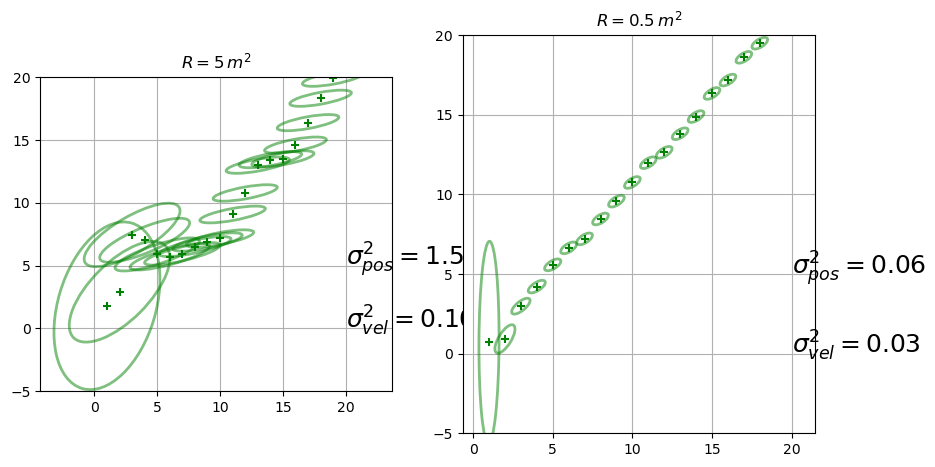

In [52]:
from kf_book.mkf_internal import plot_track_ellipses

def plot_covariances(count, R, Q=0, P=20., title=''):    
    track, zs = compute_dog_data(R, Q, count)
    f = pos_vel_filter(x=(0., 0.), R=R, Q=Q, P=P)

    xs, cov = [], []
    for z in zs:
        f.predict()
        f.update(z)

        xs.append(f.x[0])
        cov.append(f.P)
    plot_track_ellipses(count, zs, xs, cov, title)

plt.figure(figsize=(10,6))
plt.subplot(121)
plot_covariances(R=5, Q=.02, count=20, title='$R = 5\, m^2$')
plt.subplot(122)
plot_covariances(R=.1, Q=.02, count=20, title='$R = 0.5\, m^2$')

If you are viewing this in Jupyter Notebook or on the web, here is an animation of the filter filtering the data. I've tuned the filter parameters such that it is easy to see a change in $\mathbf P$ as the filter progresses.

如果你在 Jupyter Notebook 中或在网页上查看本书，下面是一段展示滤波器对数据进行滤波的动画。我已调整滤波器参数，使得随着滤波器推进，$\mathbf P$ 的变化易于观察。

<img src='animations/multivariate_track1.gif'>


The output on these is a bit messy, but you should be able to see what is happening. In both plots we are drawing the covariance matrix for each point. We start with the covariance $\mathbf P=(\begin{smallmatrix}20&0\\0&20\end{smallmatrix})$, which signifies a lot of uncertainty about our initial belief. After we receive the first measurement the Kalman filter updates this belief, and so the variance is no longer as large. In the top plot the first ellipse (the one on the far left) should be a slightly squashed ellipse. As the filter continues processing the measurements the covariance ellipse quickly shifts shape until it settles down to being a long, narrow ellipse tilted in the direction of movement.

这些图的输出有些杂乱，但你应该能够看出发生了什么。在两幅图中，我们都为每个点绘制了协方差矩阵。我们从协方差 $\mathbf P=(\begin{smallmatrix}20&0\\0&20\end{smallmatrix})$ 开始，它表示我们对初始信念存在很大的不确定性。收到第一次测量后，卡尔曼滤波器会更新这一信念，因此方差不再那么大。在上图中，第一个椭圆，即最左侧的椭圆，应当是略微压扁的椭圆。随着滤波器继续处理测量值，协方差椭圆会迅速改变形状，最终稳定为沿运动方向倾斜的细长椭圆。

Think about what this means physically. The x-axis of the ellipse denotes our uncertainty in position, and the y-axis our uncertainty in velocity. So, an ellipse that is taller than it is wide signifies that we are more uncertain about the velocity than the position. Conversely, a wide, narrow ellipse shows high uncertainty in position and low uncertainty in velocity. Finally, the amount of tilt shows the amount of correlation between the two variables. 

请从物理意义上思考这意味着什么。椭圆的 x 轴表示我们对位置的不确定性，y 轴表示我们对速度的不确定性。因此，一个高大于宽的椭圆表示我们对速度的不确定性大于对位置的不确定性。相反，一个宽而扁的椭圆表示位置的不确定性高，而速度的不确定性低。最后，倾斜程度显示两个变量之间的相关程度。

The first plot, with $R=5 m^2$, finishes up with an ellipse that is wider than it is tall. If that is not clear I have printed out the variances for the last ellipse in the lower right hand corner.

第一幅图中，$R=5 m^2$，最终的椭圆比它高更宽。如果这还不够清楚，我已在右下角打印出最后一个椭圆的方差。

In contrast, the second plot, with `R=0.5` $m^2$, has a final ellipse that is taller than wide. The ellipses in the second plot are all much smaller than the ellipses in the first plot. This stands to reason because a small $\small\mathbf R$ implies a small amount of noise in our measurements. Small noise means accurate predictions, and thus a strong belief in our position. 

相比之下，第二幅图中，`R=0.5` $m^2$，最终的椭圆高于宽。第二幅图中的所有椭圆都远小于第一幅图中的椭圆。这是合理的，因为较小的 $\small\mathbf R$ 表示测量中的噪声较小。较小的噪声意味着预测准确，因此我们对位置具有很强的信念。


## Question: Explain Ellipse Differences
## 问题：解释椭圆差异

Why are the ellipses for $\mathbf R=5 m^2$ more tilted towards the horizontal than the ellipses for $\mathbf R=0.5 m^2$. Hint: think about this in the context of what these ellipses mean physically, not in terms of the math. If you aren't sure about the answer,change $\mathbf R$ to truly large and small numbers such as 100 $m^2$ and 0.1 $m^2$, observe the changes, and think about what this means. 

为什么 $\mathbf R=5 m^2$ 时的椭圆比 $\mathbf R=0.5 m^2$ 时的椭圆更趋向于水平倾斜？提示：请从这些椭圆的物理含义出发思考，而不是从数学角度思考。如果你不确定答案，请将 $\mathbf R$ 改为真正很大和很小的数值，例如 100 $m^2$ 和 0.1 $m^2$，观察变化，并思考这些变化意味着什么。


### Solution
### 解答

The x-axis is for position, and y-axis is velocity. An ellipse that is vertical, or nearly so, says there is no correlation between position and velocity, and an ellipse that is diagonal says that there is a lot of correlation. Phrased that way, the results sound unlikely. The tilt of the ellipse changes, but the correlation shouldn't be changing over time. But this is a measure of the *output of the filter*, not a description of the actual, physical world. When $\mathbf R$ is very large we are telling the filter that there is a lot of noise in the measurements. In that case the Kalman gain $\mathbf K$ is set to favor the prediction over the measurement, and the prediction comes from the velocity state variable. Thus there is a large correlation between $x$ and $\dot x$. Conversely, if $\mathbf R$ is small, we are telling the filter that the measurement is very trustworthy, and $\mathbf K$ is set to favor the measurement over the prediction. Why would the filter want to use the prediction if the measurement is nearly perfect? If the filter is not using much from the prediction there will be very little correlation reported. 

x 轴表示位置，y 轴表示速度。竖直或近乎竖直的椭圆表示位置与速度之间没有相关性，而对角方向的椭圆表示二者之间存在很强的相关性。这样表述时，结果听起来不太可信。椭圆的倾斜程度在变化，但相关性不应随时间变化。然而，这衡量的是*滤波器的输出*，而不是对真实物理世界的描述。当 $\mathbf R$ 很大时，我们是在告诉滤波器测量中存在大量噪声。在这种情况下，卡尔曼增益 $\mathbf K$ 被设定为偏向预测而非测量，而预测来自速度状态变量。因此，$x$ 与 $\dot x$ 之间存在很强的相关性。反过来，若 $\mathbf R$ 很小，我们就是在告诉滤波器测量值非常可信，且 $\mathbf K$ 被设定为偏向测量而非预测。如果测量近乎完美，滤波器为什么还要使用预测？若滤波器很少采用预测，报告出的相关性就会很小。

**This is a critical point to understand!**. The Kalman filter is a mathematical model for a real world system. A report of little correlation *does not mean* there is no correlation in the physical system, just that there was no *linear* correlation in the mathematical model. It's a report of how much measurement vs prediction was incorporated into the model.  

**这是一个必须理解的关键点！**卡尔曼滤波器是现实世界系统的数学模型。报告出较弱的相关性*并不意味着*物理系统中不存在相关性，只意味着数学模型中不存在*线性*相关性。它反映的是模型中纳入了多少测量信息与预测信息。

Let's bring that point home with a truly large measurement error. We will set $\mathbf R=200\, m^2$. Think about what the plot will look like before looking at it.

让我们用一个真正很大的测量误差来进一步说明这一点。我们将设定 $\mathbf R=200\, m^2$。在查看图之前，先想想它会是什么样子。


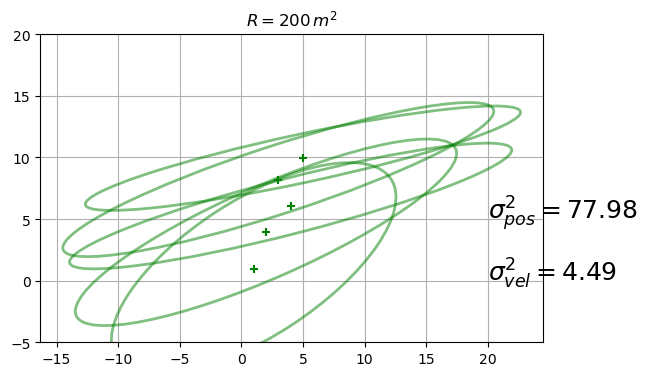

In [53]:
plot_covariances(R=200., Q=.2, count=5, title='$R = 200\, m^2$')

I hope the result was what you were expecting. The ellipse quickly became very wide and not very tall. It did this because the Kalman filter mostly used the prediction vs the measurement to produce the filtered result. We can also see how the filter output is slow to acquire the track. The Kalman filter assumes that the measurements are extremely noisy, and so it is very slow to update its estimate for $\dot x$. 

希望结果符合你的预期。椭圆很快变得很宽而不太高。这是因为卡尔曼滤波器主要使用预测而非测量来生成滤波结果。我们还可以看到，滤波器输出缓慢地获得轨迹。卡尔曼滤波器假设测量值的噪声极大，因此它更新对 $\dot x$ 的估计非常缓慢。

Keep looking at these plots until you grasp how to interpret the covariance matrix $\mathbf P$. When you work with a $9{\times}9$ matrix it may seem overwhelming - there are 81 numbers to interpret. Just break it down - the diagonal contains the variance for each state variable, and all off diagonal elements are the product of two variances and a scaling factor $p$. You cannot plot a $9{\times}9$ matrix on the screen so you have to develop your intuition and understanding in this simple, 2-D case. 

继续观察这些图，直到你掌握如何解读协方差矩阵 $\mathbf P$。当你处理一个 $9{\times}9$ 矩阵时，可能会觉得难以应对，因为有 81 个数字需要解读。只要将其拆开来看即可：对角线包含每个状态变量的方差，所有非对角元素都是两个方差与缩放因子 $p$ 的乘积。你无法在屏幕上绘制一个 $9{\times}9$ 矩阵，因此必须通过这个简单的二维情形培养直觉和理解。

>When plotting covariance ellipses, make sure to always use ax.set_aspect('equal') or plt.axis('equal') in your code (the former lets you set the xlim and ylim values). If the axis use different scales the ellipses will be drawn distorted. For example, the ellipse may be drawn as being taller than it is wide, but it may actually be wider than tall.

>绘制协方差椭圆时，请务必始终在代码中使用 ax.set_aspect('equal') 或 plt.axis('equal')，前者允许你设置 xlim 和 ylim 值。如果坐标轴使用不同的比例，椭圆将被失真绘制。例如，椭圆可能被画成高于宽，但实际上可能宽于高。


## Filter Initialization
## 滤波器初始化

There are many schemes for initializing the filter. The following approach performs well in most situations. In this scheme you do not initialize the filter until you get the first measurement, $\mathbf z_0$. From this you can compute the initial value for $\mathbf x$ with $\mathbf x_0 = \mathbf z_0$. If  $\mathbf z$ is not of the same size, type, and units as $\mathbf x$, which is usually the case, we can use our measurement function as follow.

初始化滤波器的方法有很多。下面的方法在大多数情况下都表现良好。按照这种方法，直到获得第一个测量值 $\mathbf z_0$ 时才初始化滤波器。由此可通过 $\mathbf x_0 = \mathbf z_0$ 计算 $\mathbf x$ 的初始值。如果 $\mathbf z$ 与 $\mathbf x$ 的大小、类型和单位不同，而这通常正是实际情况，我们可以按如下方式使用测量函数。

We know

我们知道

$$\mathbf z = \mathbf{Hx}$$

Hence,

因此，

$$\begin{aligned}
\mathbf H^{-1}\mathbf{Hx} &= \mathbf H^{-1}\mathbf z \\
\mathbf x &= \mathbf H^{-1}\mathbf z\end{aligned}$$

Matrix inversion requires a square matrix, but $\mathbf H$ is rarely square. SciPy will compute the Moore-Penrose pseudo-inverse of a matrix with `scipy.linalg.pinv`, so your code might look like

矩阵求逆要求矩阵为方阵，但 $\mathbf H$ 很少是方阵。SciPy 可用 `scipy.linalg.pinv` 计算矩阵的 Moore-Penrose 伪逆，因此代码可能如下所示。


In [54]:
from scipy.linalg import pinv

H = np.array([[1, 0.]]) 
z0 = 3.2
x = np.dot(pinv(H), z0)
print(x)

[[3.2]
 [0. ]]


Specialized knowledge of your problem domain may lead you to a different computation, but this is one way to do it. For example, if the state includes velocity you might take the first two measurements of position, compute the difference, and use that as the initial velocity.

对问题领域的专业知识可能会使你采用不同的计算方法，但这是一种可行的做法。例如，若状态包含速度，可以取前两个位置测量值，计算它们的差，并将其作为初始速度。

Now we need to compute a value for $\mathbf P$. This will vary by problem, but in general you will use the measurement error $\mathbf R$ for identical terms, and maximum values for the rest of the terms. Maybe that isn't clear. In this chapter we have been tracking and object using position and velocity as the state, and the measurements have been positions. In that case we would initialize $\mathbf P$ with

现在需要计算 $\mathbf P$ 的值。它因问题而异，但通常会对相同的项使用测量误差 $\mathbf R$，对其余项使用最大值。这一点或许不够清楚。本章中，我们一直使用位置和速度作为状态来跟踪一个对象，测量值则是位置。在这种情况下，可以用下式初始化 $\mathbf P$：

$$\mathbf P = \begin{bmatrix}\mathbf R_0 & 0 \\0 & vel_{max}^2\end{bmatrix}$$

The diagonal of $\mathbf P$ contains the variance of each state variable, so we populate it with reasonable values. $\mathbf R_0$ is a reasonable variance for the position, and the maximum velocity squared is a reasonable variance for the velocity. It is squared because variance is squared: $\sigma^2$.

$\mathbf P$ 的对角线包含各个状态变量的方差，因此我们为其填入合理的值。$\mathbf R_0$ 是位置的合理方差，最大速度的平方则是速度的合理方差。之所以取平方，是因为方差本身就是平方量：$\sigma^2$。

You really need to understand the domain in which you are working and initialize your filter on the best available information. For example, suppose we were trying to track horses in a horse race. The initial measurements might be very bad, and provide you with a position far from the starting gate. We know that the horse must start at the starting gate; initializing the filter to the initial measurement would lead to suboptimal results. In this scenario we would want to always initialize the Kalman filter with the starting gate position of the horse.

你确实需要了解自己所处理的领域，并依据可获得的最佳信息初始化滤波器。例如，假设我们要跟踪赛马中的马匹。初始测量值可能很差，给出一个远离起跑闸门的位置。我们知道马一定从起跑闸门出发，若用初始测量值初始化滤波器，结果将不是最优的。在这种情形下，应始终用马匹在起跑闸门处的位置初始化卡尔曼滤波器。


## Batch Processing
## 批处理

The Kalman filter is designed as a recursive algorithm - as new measurements come in we immediately create a new estimate. But it is very common to have a set of data that have been already collected which we want to filter. Kalman filters can be run in a batch mode, where all of the measurements are filtered at once. We have implemented this in `KalmanFilter.batch_filter()`. Internally, all the function does is loop over the measurements and collect the resulting state and covariance estimates in arrays. It simplifies your logic and conveniently gathers all of the outputs into arrays. I often use this function, but waited until the end of the chapter so you would become very familiar with the predict/update cyle that you must run.

卡尔曼滤波器被设计为递归算法，新测量值一到来，我们便立即生成新的估计。但我们经常会有一组已收集、希望进行滤波的数据。卡尔曼滤波器可以在批处理模式下运行，一次滤波所有测量值。我们在 `KalmanFilter.batch_filter()` 中实现了这一功能。该函数在内部仅遍历测量值，并将得到的状态估计和协方差估计收集到数组中。它能简化逻辑，并方便地将所有输出汇集为数组。我经常使用这个函数，但把它留到本章末尾介绍，是为了让你充分熟悉必须执行的预测/更新循环。

First collect your measurements into an array or list. Maybe it is in a CSV file:

首先将测量值收集到数组或列表中。它们可能存放在 CSV 文件里：

```python
zs = read_altitude_from_csv('altitude_data.csv')
```

Or maybe you will generate it using a generator:

或者，你会用生成器来生成它：

```python
zs = [some_func(i) for i in range(1000)]
```

Then call the `batch_filter()` method.

然后调用 `batch_filter()` 方法。

```python
Xs, Ps, Xs_prior, Ps_prior = kfilter.batch_filter(zs)
```

The function takes the list of measurements, filters it, and returns an  NumPy array of state estimates (Xs), covariance matrices (Ps), and the priors for the same (Xs_prior, Ps_prior).

该函数接收测量值列表，对其进行滤波，并返回包含状态估计 (Xs)、协方差矩阵 (Ps)，以及相应先验 (Xs_prior, Ps_prior) 的 NumPy 数组。

Here is a complete example.

下面是一个完整示例。


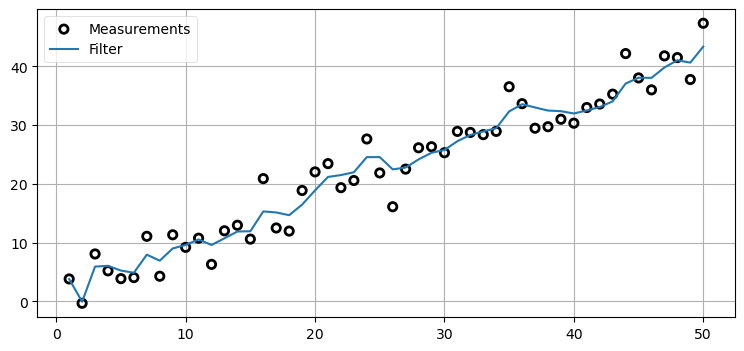

In [55]:
count = 50
track, zs = compute_dog_data(10, .2, count)
P = np.diag([500., 49.])
f = pos_vel_filter(x=(0., 0.), R=3., Q=.02, P=P)
xs, _, _, _ = f.batch_filter(zs)

book_plots.plot_measurements(range(1, count + 1), zs)
book_plots.plot_filter(range(1, count + 1), xs[:, 0])
plt.legend(loc='best');

The batch filter takes an optional `filterpy.common.Saver` object. If provided, all of the filter's attributes will be saved as well. This is useful if you want to inspect values other than the state and covariance. Here I plot the residual to see if it appears like noise centered around 0. This is a quick visual inspection to see if the filter is well designed. If if drifts from zero, or doesn't look like noise, the filter is poorly designed and/or the processes are not Gaussian. We will discuss this in detail in later chapters. For now consider this a demonstration of the `Saver` class.

批处理滤波器接受一个可选的 `filterpy.common.Saver` 对象。若提供该对象，滤波器的所有属性也会被保存。当你想检查状态和协方差以外的值时，这很有用。这里我绘制残差，以观察它是否看起来像以 0 为中心的噪声。这是快速直观检查滤波器设计是否合理的方法。如果它偏离零点，或看起来不像噪声，那么滤波器的设计不佳，和或过程不是高斯的。我们将在后续章节详细讨论这一点。现在，只需将此视为对 `Saver` 类的演示。


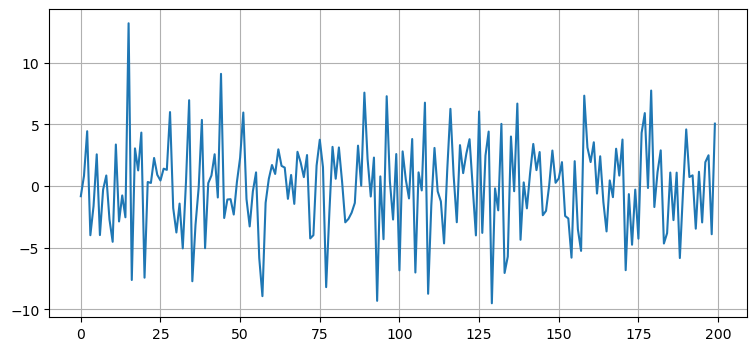

In [56]:
track, zs = compute_dog_data(10, .2, 200)
P = np.diag([500., 49.])
f = pos_vel_filter(x=(0., 0.), R=3., Q=.02, P=P)
s = Saver(f)
xs, _, _, _ = f.batch_filter(zs, saver=s)
s.to_array()
plt.plot(s.y);

## Smoothing the Results
## 对结果进行平滑

This book includes a chapter on smoothing the results; I will not repeat the information here. However, it is so easy to use, and offers such a profoundly improved output that I will tease you with a few examples. The smoothing chapter is not especially difficult; you are sufficiently prepared to read it now.

本书包含专门讲解结果平滑的一章，这里不再重复相关内容。不过，它非常易用，且能显著改善输出，因此我会用几个示例先让你一窥究竟。平滑章节并不特别困难，你现在已经具备足够的基础来阅读它。

Let's assume that we are tracking a car that has been traveling in a straight line. We get a measurement that implies that the car is starting to turn to the left. The Kalman filter moves the state estimate somewhat towards the measurement, but it cannot judge whether this is a particularly noisy measurement or the true start of a turn. 

假设我们正在跟踪一辆沿直线行驶的汽车。我们得到一个测量值，它表明汽车开始向左转弯。卡尔曼滤波器会将状态估计向该测量值适度移动，但它无法判断这究竟是一个噪声特别大的测量值，还是转弯真正开始的信号。

However, if we have future measurements we can decide if a turn was made. Suppose the subsequent measurements all continue turning left. We can then be sure that that a turn was initiated. On the other hand, if the subsequent measurements continued on in a straight line we would know that the measurement was noisy and should be mostly ignored. Instead of making an estimate part way between the measurement and prediction the estimate will either fully incorporate the measurement or ignore it, depending on what the future measurements imply about the object's movement.

然而，如果拥有未来的测量值，就能判断是否确实发生了转弯。假设后续测量值都持续向左转弯，我们便可确定转弯已经开始。反之，若后续测量值继续沿直线前进，就知道该测量值含有噪声，应大体忽略它。估计值不再取测量值与预测值之间的某个位置，而是会完全纳入该测量值或忽略它，取决于未来测量值对对象运动所作出的表明。

`KalmanFilter` implements a form of this algorithm which is called an *RTS smoother*, named after the inventors of the algorithm: Rauch, Tung, and Striebel. The method is `rts_smoother()`. To use it pass in the means and covariances computed from the `batch_filter` step, and receive back the smoothed means, covariances, and Kalman gain. 

`KalmanFilter` 实现了该算法的一种形式，称为 *RTS smoother*，以该算法的发明者 Rauch、Tung 和 Striebel 命名。其方法为 `rts_smoother()`。使用时，传入 `batch_filter` 步骤计算得到的均值和协方差，即可获得平滑后的均值、协方差和卡尔曼增益。


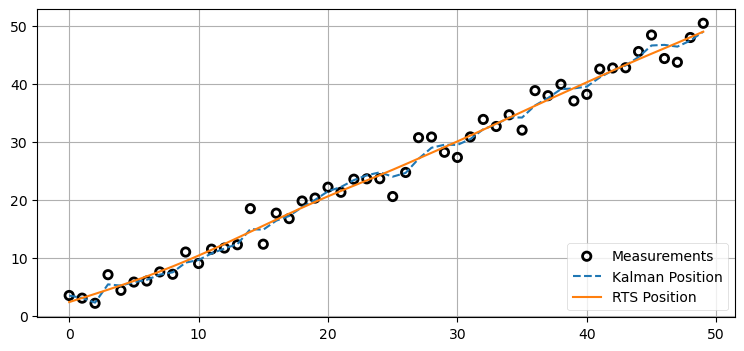

In [57]:
from numpy.random import seed
count = 50
seed(8923)

P = np.diag([500., 49.])
f = pos_vel_filter(x=(0., 0.), R=3., Q=.02, P=P)
track, zs = compute_dog_data(3., .02, count)
Xs, Covs, _, _ = f.batch_filter(zs)
Ms, Ps, _, _ = f.rts_smoother(Xs, Covs)

book_plots.plot_measurements(zs)
plt.plot(Xs[:, 0], ls='--', label='Kalman Position')
plt.plot(Ms[:, 0], label='RTS Position')
plt.legend(loc=4);

This output is fantastic! Two things are very apparent to me in this chart. First, the RTS smoother's output is much smoother than the KF output. Second, it is almost always more accurate than the KF output (we will examine this claim in detail in the **Smoothing** chapter). The improvement in the velocity, which is a hidden variable, is even more dramatic:

这个输出非常出色！从图中可以清楚看出两点。第一，RTS 平滑器的输出比 KF 的输出平滑得多。第二，它几乎总是比 KF 的输出更准确，关于这一说法我们会在 **Smoothing** 章节中详细考察。速度作为隐藏变量，其改进更加显著：


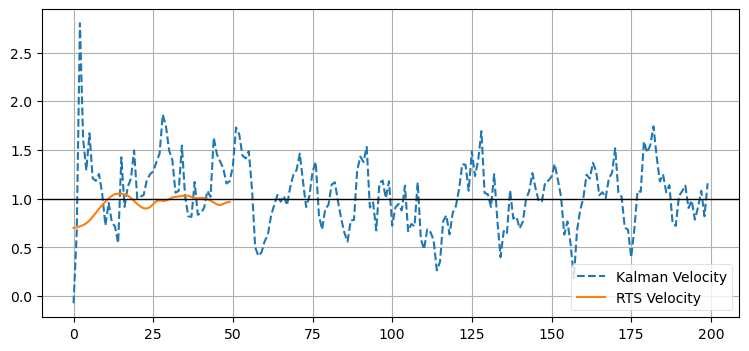

In [58]:
plt.plot(xs[:, 1], ls='--', label='Kalman Velocity')
plt.plot(Ms[:, 1], label='RTS Velocity')
plt.legend(loc=4)
plt.gca().axhline(1, lw=1, c='k');

We will explore why this is so in the next exercise.

我们将在下一道练习中探究原因。


## Exercise: Compare Velocities
## 练习：比较速度

Since we are plotting velocities let's look at what the 'raw' velocity is, which we can compute by subtracting subsequent measurements. i.e the velocity at time 1 can be approximated by `xs[1] - xs[0]`. Plot the raw value against the values estimated by the Kalman filter and by the RTS filter. Discuss what you see.

既然要绘制速度图，就来看看“原始”速度是什么，它可以通过相邻测量值相减来计算。也就是说，时刻 1 的速度可近似为 `xs[1] - xs[0]`。请将原始值与卡尔曼滤波器和 RTS 滤波器估计出的值绘制在一起，并讨论你观察到的现象。


In [59]:
# your code here

### Solution
### 解答


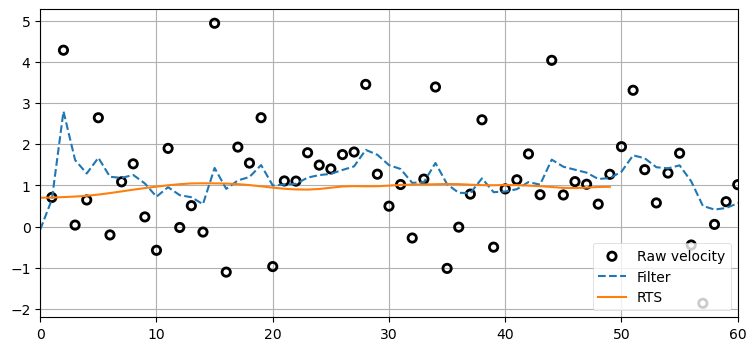

In [60]:
dx = np.diff(xs[:, 0], axis=0)
plt.scatter(range(1, len(dx) + 1), dx, facecolor='none', 
            edgecolor='k', lw=2, label='Raw velocity')
plt.plot(xs[:, 1], ls='--', label='Filter')
plt.plot(Ms[:, 1], label='RTS')
plt.xlim(0, 60)
plt.legend(loc=4);

We see that the noise swamps the signal, causing the raw values to be essentially worthless. The filter is maintaining a separate estimate for velocity. The Kalman gain $\mathbf K$ is multidimensional. For example, it might have the value  $\mathbf K = [0.1274, 0.843]^\mathsf T$. the first value is used to scale the residual of the position, and the second value will scale the residual of the velocity. The covariance matrix tells the filter how correlated the position and velocity are, and each will be optimally filtered. 

可以看到，噪声淹没了信号，使原始值基本毫无价值。滤波器会为速度维持单独的估计。卡尔曼增益 $\mathbf K$ 是多维的。例如，它可能取值为 $\mathbf K = [0.1274, 0.843]^\mathsf T$。第一个值用于缩放位置的残差，第二个值则用于缩放速度的残差。协方差矩阵会告诉滤波器位置和速度之间的相关程度，并分别对它们进行最优滤波。

I show this to reiterate the importance of using Kalman filters to compute velocities, accelerations, and even higher order values. I use a Kalman filter even when my measurements are so accurate that I am willing to use them unfiltered because it allows me accurate estimates for velocities and accelerations.

我展示这一点，是为了再次强调使用卡尔曼滤波器计算速度、加速度乃至更高阶量的重要性。即使我的测量值准确到足以直接使用，我仍会使用卡尔曼滤波器，因为它能让我获得准确的速度和加速度估计。


## Discussion and Summary
## 讨论与总结

Multivariate Gaussians allow us to simultaneously handle multiple dimensions, both spacial and others (velocity, etc). We made a key insight: hidden variables have the ability to significantly increase the accuracy of the filter. This is possible because the hidden variables are correlated with the observed variables. 

多元高斯分布使我们能够同时处理多个维度，包括空间维度和其他维度，例如速度。我们得到了一个关键认识：隐藏变量能够显著提高滤波器的准确性。这是因为隐藏变量与观测变量存在相关性。

I gave an intuitive definition of *observability*. Observability was invented by Dr. Kalman for linear systems, and there is a fair amount of theory behind it. It answers the question of whether a system state can be determined by observing the system's output. For our problems this has been easy to determine, but more complicated systems may require rigorous analysis. Wikipedia's [Observability](https://en.wikipedia.org/wiki/Observability) article has an overview; if you need to learn the topic [[2]](#References) is a good source. 

我给出了*可观测性*的直观定义。可观测性由 Kalman 博士为线性系统提出，其背后有相当丰富的理论。它回答的问题是，能否通过观测系统输出确定系统状态。对我们的问题而言，这很容易判断，但更复杂的系统可能需要严格分析。Wikipedia 的 [Observability](https://en.wikipedia.org/wiki/Observability) 条目提供了概述；若想学习这个主题，[[2]](#References) 是很好的资料来源。

There is one important caveat about hidden variables. It is easy to construct a filter that produces estimates for hidden variables. I could write a filter that estimates the color of a tracked car. But there is no way to compute car color from positions, so the estimate for the color will be nonsense. The designer must verify that these variables are being estimated correctly. If you do not have a velocity sensor and yet are estimating velocity, you will need to test that the velocity estimates are correct.; do not trust that they are. For example, suppose the velocity has a periodic component to it - it looks like a sine wave. If your sample time is less than 2 times the frequency you will not be able to accurately estimate the velocity (due to Nyquist's Theorem). Imagine that the sample period is equal to the frequency of the velocity. The filter will report that the velocity is constant because it samples the system at the same point on the sin wave. 

隐藏变量有一项重要的注意事项。构造一个能产生隐藏变量估计的滤波器很容易。我可以编写一个估计被跟踪汽车颜色的滤波器。但无法从位置计算出汽车颜色，因此颜色估计将毫无意义。设计者必须验证这些变量是否被正确估计。若没有速度传感器却在估计速度，就需要测试速度估计是否正确，不能想当然地信任它们。例如，假设速度含有周期性成分，看起来像正弦波。若采样时间小于频率的 2 倍，就无法准确估计速度，这是由奈奎斯特定理决定的。设想采样周期等于速度的频率。滤波器会报告速度恒定，因为它总是在正弦波的同一位置对系统采样。

Initialization poses a particularly difficult problem for hidden variables. If you start with a bad initialization the filter can usually recover the observed variables, but may struggle and fail with the hidden one. Estimating hidden variables is a powerful tool, but a dangerous one. 

初始化对隐藏变量而言是一个特别棘手的问题。如果初始值不佳，滤波器通常能够恢复观测变量，但在隐藏变量上可能会举步维艰，甚至失败。估计隐藏变量是一项强大的工具，但也有危险。

I established a series of steps for designing a Kalman filter. These are not a usual part of the Kalman filter literature, and are only meant as a guide, not a prescription. Designing for a hard problem is an iterative process. You make a guess at the state vector, work out what your measurement and state models are, run some tests, and then alter the design as necessary. 

我列出了一系列设计卡尔曼滤波器的步骤。这些并非卡尔曼滤波文献中的常规内容，只是指导而非处方。为难题进行设计是一个迭代过程。你先对状态向量作出猜测，确定测量模型和状态模型，运行一些测试，然后按需要调整设计。

The design of $\mathbf R$ and $\mathbf Q$ is often quite challenging. I've made it appear to be quite scientific. Your sensor has Gaussian noise of $\mathcal{N}(0, \sigma^2)$, so set $\mathbf R=\sigma^2$. Easy! This is a dirty lie. Sensors are not Gaussian. We started the book with a bathroom scale. Suppose $\sigma=1$ kg, and you try to weigh something that weighs 0.5 kg. Theory tells us we will get negative measurements, but of course the scale will never report weights less than zero. Real world sensors typically have *fat tails* (known as *kurtosis*) and *skew*. In some cases, such as with the scale, one or both tails are truncated.

$\mathbf R$ 和 $\mathbf Q$ 的设计往往相当困难。我把它说得好像很科学。你的传感器具有 $\mathcal{N}(0, \sigma^2)$ 的高斯噪声，所以令 $\mathbf R=\sigma^2$。很简单！这却是一个彻头彻尾的谎言。传感器并不服从高斯分布。本书开头用过一台浴室体重秤。假设 $\sigma=1$ kg，而你尝试称量一个重 0.5 kg 的物体。理论告诉我们会得到负的测量值，但体重秤当然绝不会报告小于零的重量。现实世界中的传感器通常具有*肥尾*，也就是*峰度*，以及*偏度*。在某些情形下，例如这台秤，一个或两个尾部会被截断。

The case with $\mathbf Q$ is more dire. I hope you were skeptical when I blithely assigned a noise matrix to my prediction about the movements of a dog. Who can say what a dog will do next? The Kalman filter in my GPS doesn't know about hills, the outside winds, or my terrible driving skills. Yet the filter requires a precise number to encapsulate all of that information, and it needs to work while I drive off-road in the desert, and when a Formula One champion drives on a track.

$\mathbf Q$ 的情形更加严峻。希望你曾质疑过我轻率地为狗的运动预测指定噪声矩阵的做法。谁能说准一只狗下一步会做什么？我的 GPS 中的卡尔曼滤波器不了解山丘、外部风力，或我糟糕的驾驶技术。然而，滤波器需要一个精确的数值来概括所有这些信息，而且无论我在沙漠中越野驾驶，还是一级方程式冠军在赛道上驾驶，它都必须能工作。

These problems led some researchers and engineers to derogatorily call the Kalman filter a 'ball of mud'. In other words, it doesn't always hold together so well. Another term to know - Kalman filters can become *smug*. Their estimates are based solely on what you tell it the noises are. Those values can lead to overly confident estimates. $\mathbf P$ gets smaller and smaller while the filter is actually becoming more and more inaccurate! In the worst case the filter diverges. We will see a lot of that when we start studying nonlinear filters. 

这些问题使一些研究人员和工程师贬称卡尔曼滤波器为“一团泥”。换言之，它并不总是能很好地维系在一起。还有一个需要了解的说法，卡尔曼滤波器会变得*自满*。它的估计完全基于你告诉它的噪声情况。这些数值可能导致过度自信的估计。$\mathbf P$ 越来越小，而滤波器实际上却越来越不准确！在最坏的情形下，滤波器会发散。开始研究非线性滤波器时，我们将大量看到这种情况。

The Kalman filter is a mathematical model of the world. The output is only as accurate as that model. To make the math tractable we had to make some assumptions. We assume that the sensors and motion model have Gaussian noise. We assume that everything is linear. If that is true, the Kalman filter is *optimal* in a least squares sense. This means that there is no way to make a better estimate than what the filter gives us. However, these assumption are almost never true, and hence the model is necessarily limited, and a working filter is rarely optimal.

卡尔曼滤波器是世界的数学模型。输出的准确性取决于该模型的准确性。为了使数学问题可解，我们不得不作出一些假设。我们假设传感器和运动模型具有高斯噪声，假设一切都是线性的。如果这是真的，卡尔曼滤波器在最小二乘意义下就是*最优的*。这意味着不存在比滤波器所给估计更好的估计方法。然而，这些假设几乎从不成立，因此模型必然受限，实际工作的滤波器也很少是最优的。

In later chapters we will deal with the problem of nonlinearity. For now I want you to understand that designing the matrices of a linear filter is an experimental procedure more than a mathematical one. Use math to establish the initial values, but then you need to experiment. If there is a lot of unaccounted noise in the world (wind, etc.) you may have to make $\mathbf Q$ larger. If you make it too large the filter fails to respond quickly to changes. In the **Adaptive Filters** chapter you will learn some alternative techniques that allow you to change the filter design in real time in response to the inputs and performance, but for now you need to find one set of values that works for the conditions your filter will encounter. Noise matrices for an acrobatic plane might be different if the pilot is a student than if the pilot is an expert as the dynamics will be quite different.

在后续章节中，我们将处理非线性问题。现在，我希望你明白，设计线性滤波器的矩阵，与其说是数学过程，不如说是实验过程。用数学方法确定初始值，但接着还需要做实验。若现实世界中有大量未被考虑的噪声，例如风，你可能需要增大 $\mathbf Q$。如果将其设得过大，滤波器就无法快速响应变化。在 **Adaptive Filters** 章节中，你将学习一些替代技术，它们能让你根据输入和性能实时调整滤波器设计。但目前，你需要找到一组适合滤波器将遇到的条件的值。特技飞机的噪声矩阵在飞行员是学生和飞行员是专家时可能不同，因为其动力学会大不相同。


## References
## 参考文献


- <A name="[wiki_article]">[1]</A> 'Kalman Filters'. Wikipedia
https://en.wikipedia.org/wiki/Kalman_filter#Details

* **[Grewal2008]** Grewal, Mohinder S., Andrews, Angus P. *Kalman Filtering: Theory and Practice Using MATLAB*. Third Edition. John Wiley & Sons. 2008.
